<a href="https://colab.research.google.com/github/gautamkr1876/AIML_ClassNotes/blob/main/7.%20Advanced%20AI%20Agents/6.%20%20AI%20modalities%20of%20Speech/v2_Detailed_Notebook_For_Refernce_Speech.ipynb" target="_blank">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Audio for GenAI Engineers — from samples to a talking agent

**Who this is for:** engineers fluent with LLMs/Transformers who have never had
to *handle audio*. We treat audio as **data and tools** — but with more time we now build *just
enough* signal intuition (frequencies, sampling, pitch) to debug real audio.
You'll use the FFT as a tool, but you will not see a single Fourier-transform
derivation.

**The one idea that explains everything below:**
> A model never "hears" sound. It consumes a **tensor**. Almost every audio bug
> in production is a bug in *how that tensor was made* — wrong sample rate,
> wrong shape, wrong number range.

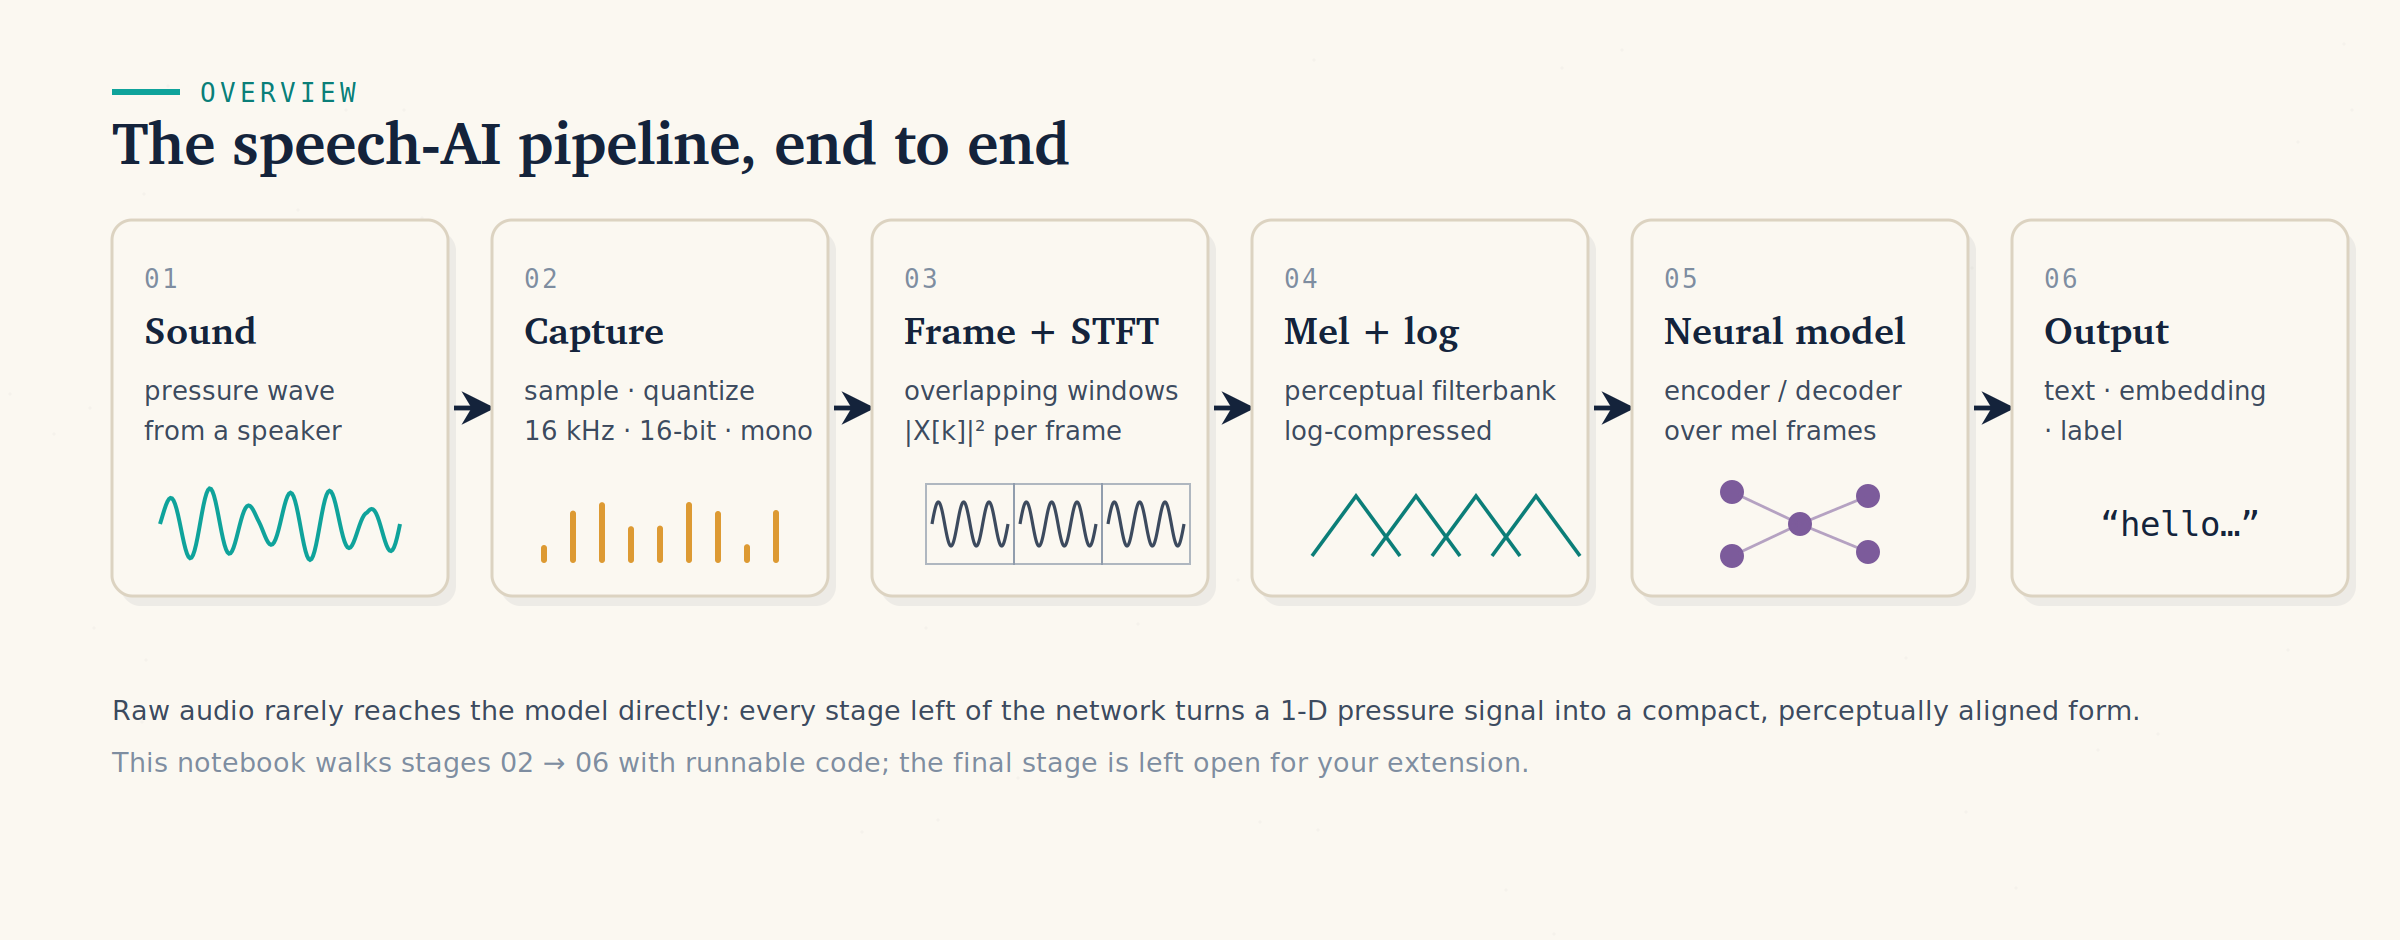
<sub><i>Everything left of the model turns a 1-D pressure signal into a compact tensor the model can read. Our whole job is getting that conversion right.</i></sub>

**What we build toward (≈150 min):**

| # | Section | What you leave with |
|---|---|---|
| 1 | Audio is an array of numbers | the mental model + the units that matter |
| 1A | Sound = a sum of frequencies | additive synthesis; the FFT as 'find the recipe' |
| 1B | Sampling & the Nyquist limit | why you need ≥2 samples per cycle |
| 1C | A man's vs a woman's voice | pitch (F0), formants, voiced/unvoiced, FFT low-pass |
| 1D | The amplitude axis: bit depth | quantization, ~6 dB/bit, file size |
| 2 | Loading audio without footguns | resampling, mono/stereo, the sample-rate disaster |
| 3 | What the model actually sees | spectrogram intuition (no math) |
| 4 | ASR with Whisper | the real knobs + hallucination / VAD / WER |
| 5 | Long audio: chunking & timestamps | transcribe files longer than 30 s |
| 6 | Giving it a voice: TTS | text → speech, and the round trip |
| 7 | The voice-agent loop | latency, cost, API-vs-local, multimodal |

**What runs where.** §1–§3 are pure NumPy/librosa and always run. §4–§7 load
real models (Whisper, a TTS model); if a model or the network is missing
they print a clear notice + the expected output instead of crashing — so the
notebook always executes top-to-bottom.

## 0 · Setup

Core (always-on) deps: `numpy`, `librosa`, `soundfile`. Model sections also need
`torch`, `transformers`, `datasets`, `jiwer`.

> **Real-world gotcha (audio decoding).** Recent `datasets` versions decode
> audio via `torchcodec`/`ffmpeg`, which breaks on many machines. The robust
> pattern — used throughout this notebook — is to load datasets with
> `Audio(decode=False)` and decode the raw bytes ourselves with `soundfile`.
> If a model cell fails on your box, it's almost always an environment issue,
> not the code.

In [1]:
# Uncomment to install into THIS kernel. --break-system-packages survives
# locked-down ("externally managed") hosts; harmless to drop elsewhere.
# import sys
# !{sys.executable} -m pip install -q --break-system-packages \
#     numpy librosa soundfile transformers datasets jiwer accelerate scipy

In [2]:
!pip install jiwer


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [3]:
# Imports + capability detection. The DSP path needs only numpy/librosa;
# torch/transformers/datasets are OPTIONAL and reported, never hard-required.
import numpy as np
import librosa

print("numpy   ", np.__version__)
print("librosa ", librosa.__version__)

TORCH_OK = HF_OK = DATASETS_OK = False
try:
    import torch; TORCH_OK = True
    print("torch   ", torch.__version__)
except Exception as e:
    print("torch    NOT available ->", type(e).__name__)
try:
    import transformers; HF_OK = True
    print("transformers", transformers.__version__)
except Exception as e:
    print("transformers NOT available ->", type(e).__name__)
try:
    import datasets; DATASETS_OK = True
    print("datasets", datasets.__version__)
except Exception as e:
    print("datasets NOT available ->", type(e).__name__)

# Pick the best device we have. (If MPS misbehaves in a pipeline, set "cpu".)
if TORCH_OK:
    device = ("cuda" if torch.cuda.is_available()
              else "mps" if torch.backends.mps.is_available() else "cpu")
else:
    device = "cpu"
pipe_device = 0 if device == "cuda" else -1   # HF pipeline wants an int
print("device  ", device, "| pipeline device:", pipe_device)

numpy    2.3.3
librosa  0.11.0
torch    2.10.0
transformers 5.5.4
datasets 4.6.1
device   mps | pipeline device: -1


In [4]:
# Cosmetic plot style so spectrograms/waveforms read well in class.
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams.update({
    "figure.dpi": 110, "figure.facecolor": "white",
    "axes.facecolor": "#FCFAF4", "axes.grid": True,
    "grid.color": "#E6E0D4", "axes.titleweight": "bold", "font.size": 10,
})
print("plot style ready")

plot style ready


In [5]:
# ---- Configuration -------------------------------------------------------
# Whisper sizes (speed vs accuracy): tiny < base < small < medium < large-v3 <
# large-v3-turbo. We default to a small ENGLISH model so class runs fast; flip
# to the production target for the exercise in §8.
ASR_MODEL_ID = "openai/whisper-base.en"          # fast classroom default
# ASR_MODEL_ID = "openai/whisper-large-v3-turbo" # production target

# TTS: a light VITS model, no speaker embeddings, runs on CPU. (API providers
# like OpenAI / ElevenLabs are shown as a pattern in §6.)
TTS_MODEL_ID = "facebook/mms-tts-eng"

SR = 16_000   # the speech sample rate the whole notebook standardizes on
print("ASR      :", ASR_MODEL_ID)
print("TTS      :", TTS_MODEL_ID)

ASR      : openai/whisper-base.en
TTS      : facebook/mms-tts-eng


## 1 · Audio is an array of numbers (≈10 min)

Sound is air pressure wobbling over time. To digitize it we **measure that
pressure many times per second**. That's the whole idea — the result is a 1-D
array of floats, nothing more exotic than a list of numbers.

Two — and really only two — units decide what that array means:

| Knob | Controls | Typical values | Who cares |
|---|---|---|---|
| **Sample rate** (`sr`, Hz) | how *often* you measured (time axis) | 8k phone · **16k speech AI** · 24k TTS · 44.1k/48k music | **everyone — #1 footgun** |
| **Amplitude / dtype** | how each sample's *value* is stored | `float32` in [-1, 1] (models) · `int16` (files) | loaders / normalization |

> **Sample rate is the number you will get wrong.** Whisper wants 16 kHz, most
> TTS emits 24 kHz, and audio-embedding models want 48 kHz. Hand a model the wrong rate and it does
> **not** error — it returns garbage, or text at the wrong speed. Burn this in
> now and you've avoided the single most common audio bug.

Let's load a real speech clip and stare at the raw numbers.

### Diff Frequencies in Sound

In [6]:
import numpy as np
from IPython.display import Audio, display

sr = 100000
duration = 2

t = np.linspace(0, duration, sr * duration, endpoint=False)

deep_sound = 0.3 * np.sin(2 * np.pi * 100 * t)    # 100 Hz
sharp_sound = 0.3 * np.sin(2 * np.pi * 1000 * t)  # 1000 Hz

sharper_sound = 0.3 * np.sin(2 * np.pi * 10000 * t)  # 10000 Hz

upper_lim_sound = 0.3 * np.sin(2 * np.pi * 15000 * t)  # 15000 Hz



print("Deep sound: slow vibration, 100 Hz")
display(Audio(deep_sound, rate=sr))

print("Sharp sound: fast vibration, 1000 Hz")
display(Audio(sharp_sound, rate=sr))

print("Sharper sound: very fast vibration, 10000 Hz")
display(Audio(sharper_sound, rate=sr))

print("Close to Upper limit sound: even faster vibration, 15000 Hz")
display(Audio(upper_lim_sound, rate=sr))

combined_deep_and_sharp = deep_sound + sharp_sound

print("Combined deep and sharp sounds")
display(Audio(combined_deep_and_sharp, rate=sr))



Deep sound: slow vibration, 100 Hz


Sharp sound: fast vibration, 1000 Hz


Sharper sound: very fast vibration, 10000 Hz


Close to Upper limit sound: even faster vibration, 15000 Hz


Combined deep and sharp sounds


### Sampling Rate

sound frequency = how fast the sound itself vibrates

sampling rate = how fast the microphone/computer measures that sound

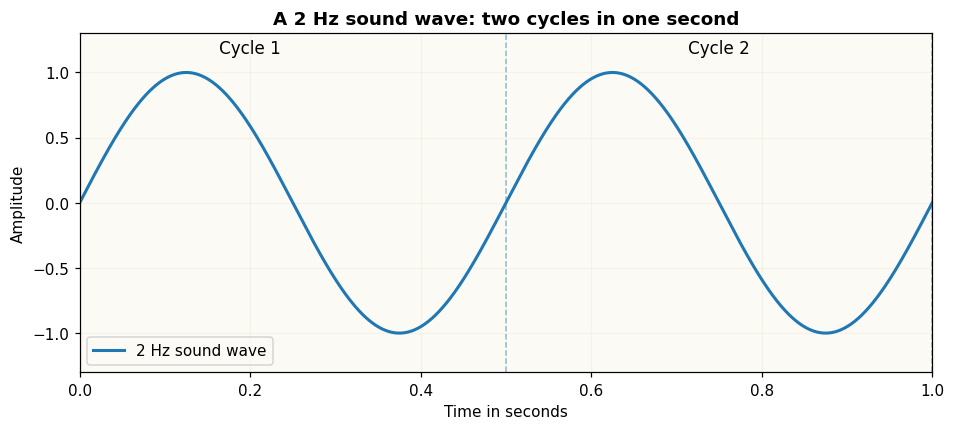

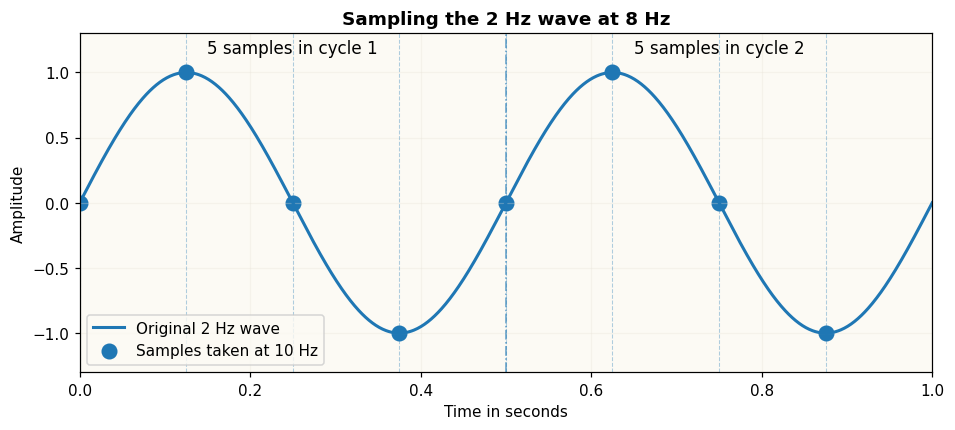

Sound frequency: 2 Hz = 2 cycles per second
Sampling rate: 8 Hz = 8 samples per second
Samples per cycle: 4.0
Sample times: [0.   0.12 0.25 0.38 0.5  0.62 0.75 0.88]
Sample values: [ 0.  1.  0. -1. -0.  1.  0. -1.]


In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Toy values for teaching
sound_frequency = 2      # 2 cycles per second
sampling_rate = 8       # 10 samples per second
duration = 1.0           # seconds

# Smooth wave for visualization
t_smooth = np.linspace(0, duration, 1000)
y_smooth = np.sin(2 * np.pi * sound_frequency * t_smooth)

# Sampled points
t_samples = np.arange(0, duration, 1 / sampling_rate)
y_samples = np.sin(2 * np.pi * sound_frequency * t_samples)

# -----------------------------
# Plot 1: Just the 2 Hz wave
# -----------------------------
plt.figure(figsize=(10, 4))
plt.plot(t_smooth, y_smooth, linewidth=2, label="2 Hz sound wave")

# Mark the two cycles
plt.axvline(0.0, linestyle="--", linewidth=1, alpha=0.5)
plt.axvline(0.5, linestyle="--", linewidth=1, alpha=0.5)
plt.axvline(1.0, linestyle="--", linewidth=1, alpha=0.5)

plt.text(0.20, 1.15, "Cycle 1", ha="center", fontsize=11)
plt.text(0.75, 1.15, "Cycle 2", ha="center", fontsize=11)

plt.title("A 2 Hz sound wave: two cycles in one second")
plt.xlabel("Time in seconds")
plt.ylabel("Amplitude")
plt.xlim(0, 1)
plt.ylim(-1.3, 1.3)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# -----------------------------
# Plot 2: Same wave + sampling dots
# -----------------------------
plt.figure(figsize=(10, 4))
plt.plot(t_smooth, y_smooth, linewidth=2, label="Original 2 Hz wave")
plt.scatter(t_samples, y_samples, s=90, label="Samples taken at 10 Hz")

# Mark every sample time
for t in t_samples:
    plt.axvline(t, linestyle="--", linewidth=0.7, alpha=0.35)

# Mark cycle boundary
plt.axvline(0.5, linestyle="-.", linewidth=1, alpha=0.7)
plt.text(0.25, 1.15, "5 samples in cycle 1", ha="center", fontsize=11)
plt.text(0.75, 1.15, "5 samples in cycle 2", ha="center", fontsize=11)

plt.title("Sampling the 2 Hz wave at " + str(sampling_rate) + " Hz")
plt.xlabel("Time in seconds")
plt.ylabel("Amplitude")
plt.xlim(0, 1)
plt.ylim(-1.3, 1.3)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print("Sound frequency:", sound_frequency, "Hz =", sound_frequency, "cycles per second")
print("Sampling rate:", sampling_rate, "Hz =", sampling_rate, "samples per second")
print("Samples per cycle:", sampling_rate / sound_frequency)
print("Sample times:", np.round(t_samples, 2))
print("Sample values:", np.round(y_samples, 2))

#### 💡 Knowledge Check: Sampling
**Q: To capture a high-pitched sound at 12 kHz, what is the minimum sample rate you must use?**

A) 6 kHz  
B) 12 kHz  
C) 24 kHz  
D) 48 kHz  

**Correct Answer: C**  
*Explanation: The Nyquist limit states you need at least 2 samples per cycle of the highest frequency (12kHz * 2 = 24kHz).*

In [8]:
# vibrating at 500 Hz (500 cycles), sampling-rate is 10000

In [9]:
# Load a real speech clip. We decode with soundfile (Audio(decode=False))
# to dodge the torchcodec/ffmpeg breakage, and cache locally for offline reruns.
import json, io
from pathlib import Path
import soundfile as sf
from IPython.display import Audio, display

CACHE = Path("audio_cache"); CACHE.mkdir(exist_ok=True)
WAV, META = CACHE / "librispeech_dummy.wav", CACHE / "librispeech_dummy_meta.json"

if WAV.exists() and META.exists():                       # 1) reuse local cache
    y, sr0 = sf.read(WAV, dtype="float32")
    meta = json.load(open(META)); ref_text, source = meta["ref_text"], meta["source"]
elif DATASETS_OK:                                        # 2) else fetch once
    from datasets import load_dataset, Audio as HFAudio
    ds = load_dataset("hf-internal-testing/librispeech_asr_dummy", "clean",
                      split="validation").cast_column("audio", HFAudio(decode=False))
    s = ds[0]; a = s["audio"]
    y, sr0 = sf.read(io.BytesIO(a["bytes"]) if a.get("bytes") else a["path"],
                     dtype="float32")
    y = np.asarray(y, np.float32); ref_text = s["text"]; source = "LibriSpeech dummy"
    sf.write(WAV, y, sr0, subtype="FLOAT")
    json.dump({"source": source, "sr": int(sr0), "ref_text": ref_text},
              open(META, "w"), indent=2)
else:
    raise RuntimeError("No cached clip and datasets unavailable -- run once with network.")

# Standardize on 16 kHz for the whole notebook (LibriSpeech is already 16k).
y16 = librosa.resample(y, orig_sr=sr0, target_sr=SR) if sr0 != SR else y

print(f"source   : {source}")
print(f"samples  : {len(y16):,}   sr: {SR} Hz   duration: {len(y16)/SR:.2f}s")
print(f"dtype    : {y16.dtype}   range: [{y16.min():+.3f}, {y16.max():+.3f}]   <- floats in [-1,1]")
print(f"reference: {ref_text!r}")
print("\n▶ listen:"); display(Audio(y16, rate=SR))

source   : LibriSpeech dummy
samples  : 93,680   sr: 16000 Hz   duration: 5.86s
dtype    : float32   range: [-0.339, +0.388]   <- floats in [-1,1]
reference: 'MISTER QUILTER IS THE APOSTLE OF THE MIDDLE CLASSES AND WE ARE GLAD TO WELCOME HIS GOSPEL'

▶ listen:


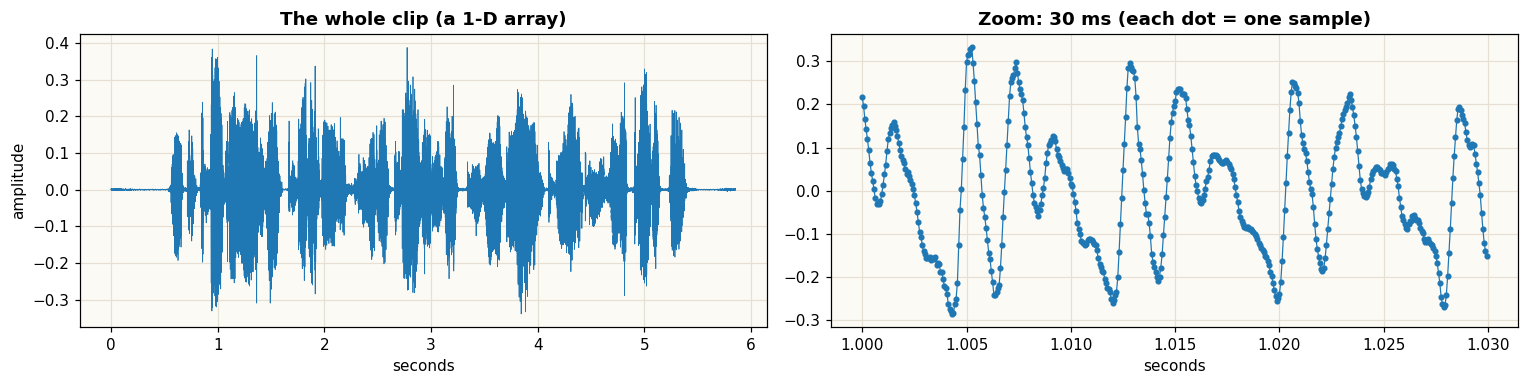

At 16000 Hz, 30 ms = 480 samples. The model reads ALL of them.


In [10]:
# It really is just numbers over time. Two pictures make that concrete:
import matplotlib.pyplot as plt
t = np.arange(len(y16)) / SR

fig, ax = plt.subplots(1, 2, figsize=(14, 3.6))
ax[0].plot(t, y16, lw=0.5)
ax[0].set(title="The whole clip (a 1-D array)", xlabel="seconds", ylabel="amplitude")

# Zoom to 30 ms: now you can SEE individual pressure samples (dots).
a, b = int(1.00 * SR), int(1.03 * SR)
ax[1].plot(t[a:b], y16[a:b], "-o", ms=3, lw=0.8)
ax[1].set(title="Zoom: 30 ms (each dot = one sample)", xlabel="seconds")
plt.tight_layout(); plt.show()

print(f"At {SR} Hz, 30 ms = {int(0.03*SR)} samples. The model reads ALL of them.")

#### 💡 Knowledge Check: Reading an audio array
**Q: A loader hands you a mono array of shape `(48000,)` for a clip you know is exactly 3 seconds long. What sample rate was it recorded at?**

A) 8 kHz  
B) 24 kHz  
C) 16 kHz  
D) 48 kHz  

**Correct Answer: C**  
*Explanation: Sample rate = samples / seconds = 48000 / 3 = 16000 Hz. The array length alone means nothing until you divide by duration.*

## 1A · A sound is a sum of frequencies (≈12 min)

Here is the single idea that makes spectrograms (§3) obvious later:

> **Any sound is just many simple sine waves — different frequencies, different
> loudnesses — added together.** A flute note, a vowel, a chord, a whole
> orchestra: all of it is one big sum of pure tones.

A **pure tone** is one frequency: `sin(2π·f·t)`. *f* (in Hz) is how many times
per second it wobbles — that is the **pitch**. Add a few tones and you get a
richer sound. The reverse direction — *given a messy wave, which tones were
added?* — is exactly what the **FFT** answers. That is the whole job of the
Fourier transform: it reads off the recipe. No derivation needed; we will just
watch it work.

In [11]:
# Three pure tones. A "tone" is literally one sine wave at one frequency.
import numpy as np
from IPython.display import Audio, display

dur   = 1.5
t     = np.linspace(0, dur, int(SR * dur), endpoint=False)   # SR = 16 kHz (from §0)
freqs = [220.0, 440.0, 660.0]          # A3, A4, E5  -> a simple chord
amps  = [1.0, 0.5, 0.33]               # higher tones a little quieter (natural)

tones = [a * np.sin(2 * np.pi * f * t) for f, a in zip(freqs, amps)]

for f, tone in zip(freqs, tones):
    print(f"{f:.0f} Hz pure tone:")
    display(Audio(0.3 * tone, rate=SR))   # 0.3 = gentle volume

220 Hz pure tone:


440 Hz pure tone:


660 Hz pure tone:


the three tones, summed into one wave:


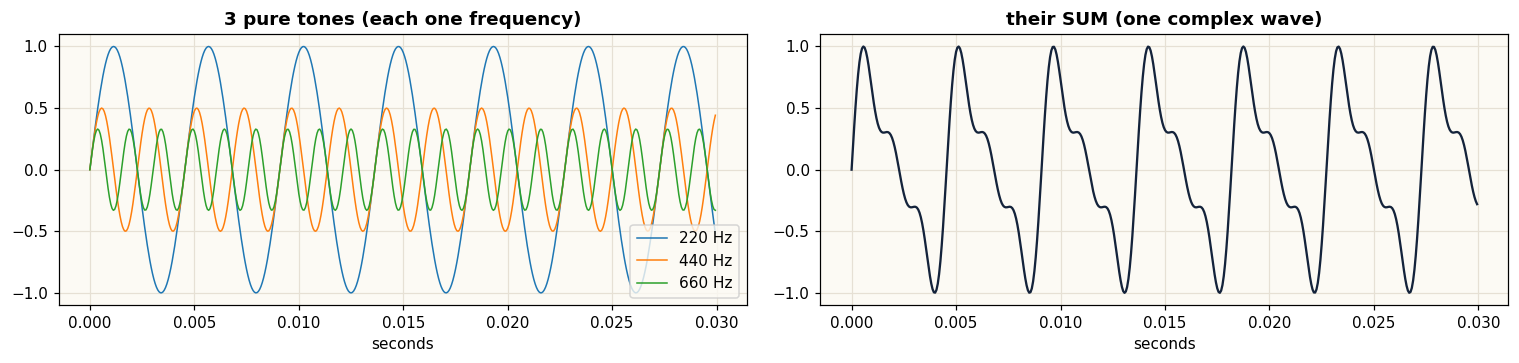

In [12]:
# Add them up. The sum is ONE array -- a single, more complex sound.
import matplotlib.pyplot as plt

mix = np.sum(tones, axis=0)
mix = mix / np.max(np.abs(mix))        # normalize into [-1, 1] so it will not clip

print("the three tones, summed into one wave:")
display(Audio(0.3 * mix, rate=SR))

# Zoom to ~30 ms so the shape is visible. One tone = a clean sine; the SUM is a
# repeating-but-complicated wave. Same information, just added together.
a, b = 0, int(0.03 * SR)
fig, ax = plt.subplots(1, 2, figsize=(14, 3.4))
for f, tone in zip(freqs, tones):
    ax[0].plot(t[a:b], tone[a:b], lw=1, label=f"{f:.0f} Hz")
ax[0].set(title="3 pure tones (each one frequency)", xlabel="seconds"); ax[0].legend()
ax[1].plot(t[a:b], mix[a:b], color="#14233B", lw=1.5)
ax[1].set(title="their SUM (one complex wave)", xlabel="seconds")
plt.tight_layout(); plt.show()

https://www.youtube.com/watch?v=spUNpyF58BY

https://www.youtube.com/watch?v=r6sGWTCMz2k&vl=en

In [13]:
spectrum  = np.abs(np.fft.rfft(mix))
spectrum

array([2.17783887e-11, 7.85336264e-12, 1.74519598e-11, ...,
       5.24138580e-12, 6.92079755e-12, 1.97361169e-12], shape=(12001,))

(0.0, 1000.0)

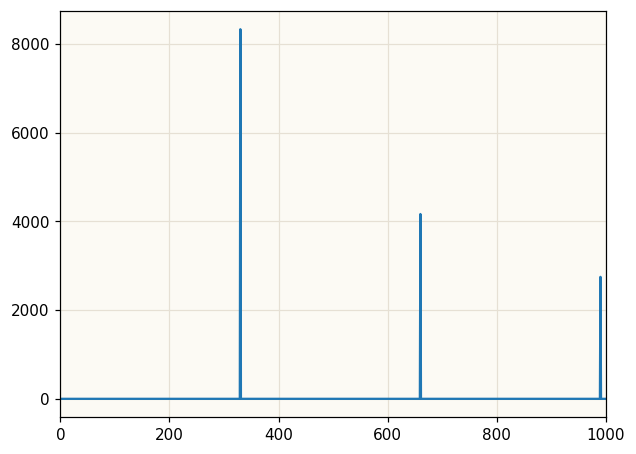

In [14]:
plt.plot(np.round(spectrum, 3))
plt.xlim(0, 1000)

In [15]:
np.unique(np.round(spectrum, 3), return_counts=True)

(array([   0.   , 2749.137, 4165.359, 8330.718]),
 array([11998,     1,     1,     1]))

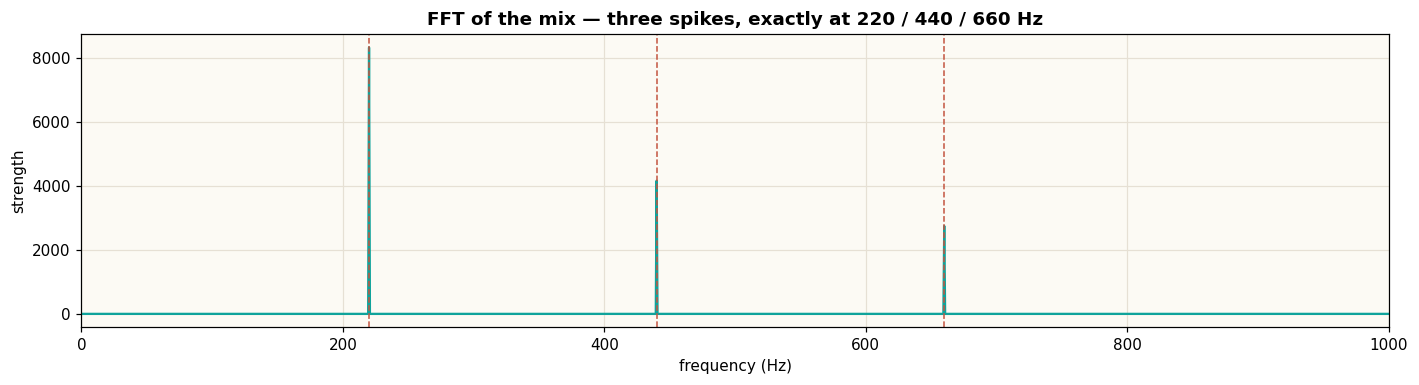

recovered frequencies (Hz): [220, 440, 660]  <- the recipe
A spectrogram (§3) is just THIS, recomputed for each short slice of time.


In [16]:
# The FFT runs the projector backwards: hand it the messy SUM and it tells you
# which pure tones were inside (and how loud). That picture is the "spectrum".
spectrum  = np.abs(np.fft.rfft(mix))          # strength of each frequency
freq_axis = np.fft.rfftfreq(len(mix), 1 / SR)

plt.figure(figsize=(13, 3.6))
plt.plot(freq_axis, spectrum, color="#0FA39B")
plt.xlim(0, 1000)                             # zoom to where our tones live
for f in freqs:
    plt.axvline(f, color="#C3543F", ls="--", lw=1)
plt.title("FFT of the mix — three spikes, exactly at 220 / 440 / 660 Hz")
plt.xlabel("frequency (Hz)"); plt.ylabel("strength"); plt.tight_layout(); plt.show()

# Read the three tallest spikes straight off the spectrum:
top = freq_axis[np.argsort(spectrum)[::-1][:3]]
print("recovered frequencies (Hz):", sorted(round(f) for f in top), " <- the recipe")
print("A spectrogram (§3) is just THIS, recomputed for each short slice of time.")

#### 💡 Knowledge Check: The FFT
**Q: If you have a 'messy' recording of a piano chord, what does the FFT allow you to do?**

A) Increase the volume of the recording without distortion  
B) Identify the specific frequencies (recipe) of the notes played  
C) Change the sample rate from 16kHz to 44.1kHz  
D) Remove background silence automatically  

**Correct Answer: B**  
*Explanation: The FFT 'runs the projector backwards', decomposing a complex wave into its individual frequency components.*

## 1B · Sampling & the Nyquist limit: why frequency ≤ ½ the sample rate (≈10 min)

To store a wave digitally we **sample** it — measure its height at a fixed rate
`SR`. How fast is fast enough? One rule governs *everything* about sample rate:

> **You need at least two samples per cycle of the highest frequency you want
> to keep.** So a sample rate `SR` can only faithfully capture frequencies up to
> `SR/2` — the **Nyquist limit**. 16 kHz speech → max 8 kHz; 44.1 kHz music →
> max 22.05 kHz; an 8 kHz phone line → max 4 kHz.

Fewer than two samples per cycle and the samples *also fit a slower wave* — the
fast tone gets mistaken for a slow one. That false low tone is **aliasing**, and
it is why §2 resamples with an anti-alias filter instead of just dropping
samples. Let's *see* it, then *hear* it.

In [17]:
# Now HEAR it. A 3 kHz tone is fine at 16 kHz (Nyquist 8 kHz). Sample the SAME
# tone at 4 kHz (Nyquist 2 kHz) with no anti-alias filter and 3 kHz folds down
# to |4000 - 3000| = 1000 Hz -- a lower pitch that was never played.
from IPython.display import Audio, display

t_hi   = np.linspace(0, 1.5, int(SR * 1.5), endpoint=False)
tone3k = 0.3 * np.sin(2 * np.pi * 3000 * t_hi)
print("3000 Hz tone at the full 16 kHz rate (correct -- a high beep):")
display(Audio(tone3k, rate=SR))

low_fs = 4000                                   # Nyquist = 2000 Hz, below 3 kHz
aliased = tone3k[:: SR // low_fs]               # naive drop = no anti-alias filter
print(f"same tone sampled at {low_fs} Hz with NO filter -> folds to "
      f"{abs(low_fs - 3000)} Hz (a LOWER beep that was never there):")
display(Audio(aliased, rate=low_fs))

3000 Hz tone at the full 16 kHz rate (correct -- a high beep):


same tone sampled at 4000 Hz with NO filter -> folds to 1000 Hz (a LOWER beep that was never there):


#### 💡 Knowledge Check: Aliasing
**Q: A pure 5 kHz tone is sampled at 8 kHz with no anti-alias filter. Because 5 kHz sits above the 4 kHz Nyquist limit, it folds down. What false frequency do you hear?**

A) 1 kHz  
B) 4 kHz  
C) 5 kHz  
D) 3 kHz  

**Correct Answer: D**  
*Explanation: A tone above Nyquist folds to |sample_rate - f| = |8000 - 5000| = 3000 Hz — a lower pitch that was never played.*

## 1C · A man's voice vs a woman's: pitch, formants, and a low-pass filter (≈15 min)

Speech is the "sum of frequencies" idea applied to a voice. Two parts (the
**source–filter** model):

- **Source = pitch.** The vocal folds open and close at the **fundamental
  frequency F0** — that is the pitch you hear. Typical **men ≈ 90–150 Hz**,
  **women ≈ 170–250 Hz**: a woman's voice literally repeats almost twice as
  fast. F0 and its multiples (harmonics) are the frequencies present.
- **Filter = vowel.** The mouth/throat shape boosts certain bands called
  **formants** — that is *which vowel* it is, roughly the same whoever speaks.

A split you will meet again at VAD (§4): **voiced** sounds (vowels) are
periodic — they have an F0 and clear frequencies; **unvoiced** sounds (s, f,
sh) are basically noise — broadband, no pitch.

We load a real **man** and **woman** saying the *same sentence*, compare their
spectra with the FFT, split one into voiced vs unvoiced, then **low-pass
filter** both — drop the high frequencies and hear them turn into muffled
"telephone" voices.

In [18]:
# Two real clips, SAME sentence, different speaker: CMU Arctic bdl (US male)
# and slt (US female). We read them from audio_cache/ (already there); on a
# fresh machine the first run downloads them once. If the network is blocked we
# SYNTHESIZE a male/female vowel (source-filter) so this always runs offline.
import numpy as np, librosa, soundfile as sf
from pathlib import Path
from IPython.display import Audio, display

CACHE = Path("audio_cache"); CACHE.mkdir(exist_ok=True)
SRC = {
    "man":   ("audio_cache/man_bdl.wav",
              "http://festvox.org/cmu_arctic/cmu_arctic/cmu_us_bdl_arctic/wav/arctic_a0001.wav"),
    "woman": ("audio_cache/woman_slt.wav",
              "http://festvox.org/cmu_arctic/cmu_arctic/cmu_us_slt_arctic/wav/arctic_a0001.wav"),
}

def fetch(url, path):                          # best-effort; cache makes this rare
    try:
        import requests
        open(path, "wb").write(requests.get(
            url, timeout=30, headers={"User-Agent": "Mozilla/5.0"}).content)
    except Exception:
        from urllib.request import urlopen, Request
        open(path, "wb").write(urlopen(
            Request(url, headers={"User-Agent": "Mozilla/5.0"}), timeout=30).read())


voices = {}
for who, (path, url) in SRC.items():
    p = Path(path)
    try:
        if not p.exists():
            fetch(url, p)
        v, sr0 = sf.read(p, dtype="float32")
        if v.ndim > 1: v = v.mean(axis=1)                  # to mono
        voices[who] = librosa.resample(v, orig_sr=sr0, target_sr=SR) if sr0 != SR else v
    except Exception as e:
        print(f"{who}: download unavailable ({type(e).__name__}) ")


man, woman = voices["man"], voices["woman"]
for who, v in [("man", man), ("woman", woman)]:
    print(f"{who:5s}: {len(v) / SR:4.1f}s")
    display(Audio(v, rate=SR))

man  :  3.2s


woman:  3.4s


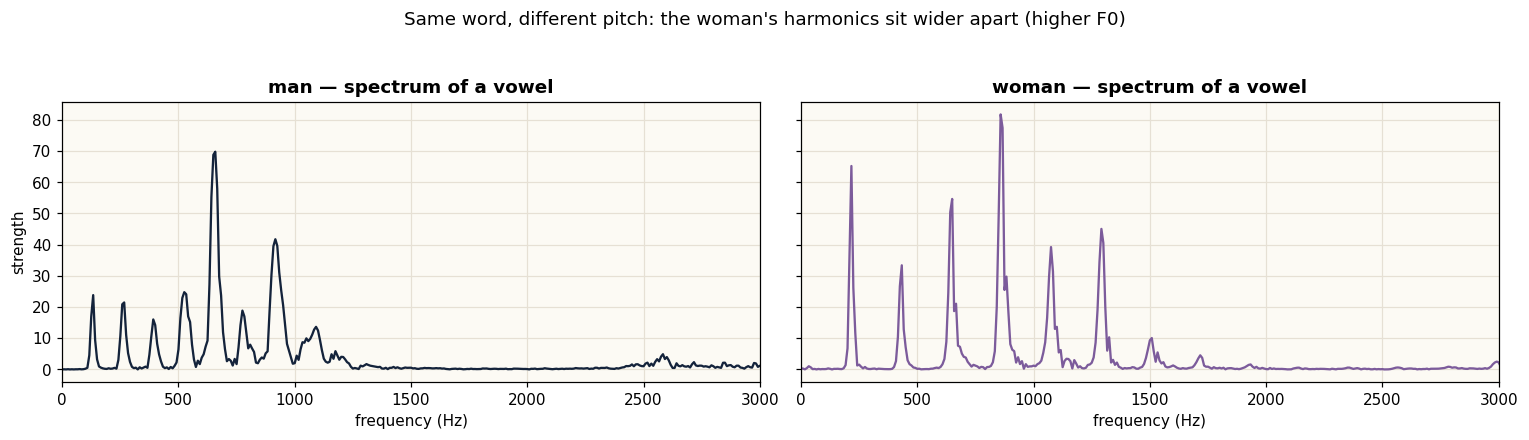

In [19]:
# Compare their frequency content. Take a short voiced (vowel) chunk from each
# and FFT it. The comb of spikes is F0 and its harmonics; the spacing between
# spikes IS the pitch -- the woman's comb is spaced wider (higher F0).
import matplotlib.pyplot as plt

def voiced_chunk(v, dur=0.12):
    i = int(np.argmax(np.abs(v)))             # near a loud (voiced) moment
    n = int(dur * SR); s = max(0, i - n // 2)
    return v[s:s + n]

fig, ax = plt.subplots(1, 2, figsize=(14, 3.8), sharey=True)
for col, (who, v, color) in zip(
        ax, [("man", man, "#14233B"), ("woman", woman, "#7C5B9B")]):
    seg = voiced_chunk(v)
    sp  = np.abs(np.fft.rfft(seg * np.hanning(len(seg))))
    fx  = np.fft.rfftfreq(len(seg), 1 / SR)
    col.plot(fx, sp, color=color)
    col.set(title=f"{who} — spectrum of a vowel", xlabel="frequency (Hz)", xlim=(0, 3000))
ax[0].set_ylabel("strength")
fig.suptitle("Same word, different pitch: the woman's harmonics sit wider apart (higher F0)", y=1.04)
plt.tight_layout(); plt.show()

### Voiced vs unvoiced speech using RMS and ZCR

Before we separate voiced and unvoiced parts, we need two simple measurements.

#### 1. RMS: how strong/loud is this short piece of audio?

RMS means Root Mean Square.

For every short frame of audio, we take all amplitude values inside that frame and summarize how energetic that frame is.

Intuition:

- high RMS: louder / stronger signal
- low RMS: silence, background, or weak signal

So RMS helps us answer:

"Is there enough sound here to treat this frame as speech?"

#### 2. ZCR: how often does the waveform cross zero?

ZCR means Zero-Crossing Rate.

The waveform has positive and negative values. A zero-crossing happens when the signal moves from positive to negative or negative to positive.

Intuition:

- low ZCR: smoother, more periodic sound
- high ZCR: noisy, hissy, rapidly changing sound

Voiced speech, like vowels, is usually more periodic and has lower ZCR.

Unvoiced speech, like "s", "f", "sh", is more noise-like and usually has higher ZCR.

This is only a teaching heuristic. Real systems use more robust voice activity detection and speech features.

Frame length: 1024 samples = 64.0 ms
Hop length:   256 samples = 16.0 ms

RMS tells us how strong/loud each short frame is.
ZCR tells us how often the waveform crosses zero inside each frame.


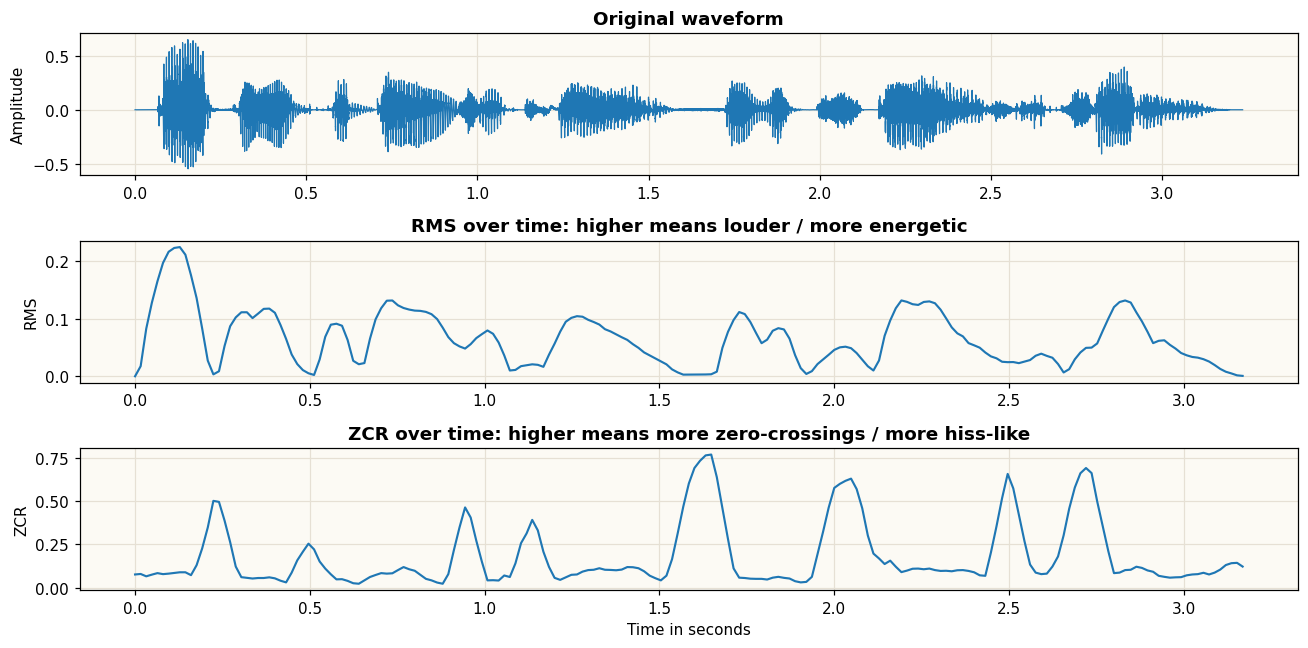

In [20]:
import numpy as np
import librosa
import matplotlib.pyplot as plt
from IPython.display import Audio, display

frame_length = 1024
hop_length = 256

frames = librosa.util.frame(man, frame_length=frame_length, hop_length=hop_length)

rms = np.sqrt(np.mean(frames ** 2, axis=0))

zcr = librosa.feature.zero_crossing_rate(
    man,
    frame_length=frame_length,
    hop_length=hop_length,
    center=False
)[0]

frame_times = librosa.frames_to_time(
    np.arange(len(rms)),
    sr=SR,
    hop_length=hop_length
)

frame_ms = 1000 * frame_length / SR
hop_ms = 1000 * hop_length / SR

print(f"Frame length: {frame_length} samples = {frame_ms:.1f} ms")
print(f"Hop length:   {hop_length} samples = {hop_ms:.1f} ms")
print()
print("RMS tells us how strong/loud each short frame is.")
print("ZCR tells us how often the waveform crosses zero inside each frame.")

plt.figure(figsize=(12, 6))

plt.subplot(3, 1, 1)
time = np.arange(len(man)) / SR
plt.plot(time, man, linewidth=0.8)
plt.title("Original waveform")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(3, 1, 2)
plt.plot(frame_times, rms, linewidth=1.4)
plt.title("RMS over time: higher means louder / more energetic")
plt.ylabel("RMS")
plt.grid(True)

plt.subplot(3, 1, 3)
plt.plot(frame_times, zcr, linewidth=1.4)
plt.title("ZCR over time: higher means more zero-crossings / more hiss-like")
plt.xlabel("Time in seconds")
plt.ylabel("ZCR")
plt.grid(True)

plt.tight_layout()
plt.show()

In [21]:
# Voiced vs unvoiced, made audible. Cut the man's clip into short frames and
# sort each as voiced (loud + few zero-crossings = periodic) or unvoiced
# (quieter + many zero-crossings = hiss), then play each group alone.
# (RMS + zero-crossings is a teaching heuristic only -- real systems use VAD, §4.)
import numpy as np, librosa
from IPython.display import Audio, display

frames = librosa.util.frame(man, frame_length=1024, hop_length=256)
rms = np.sqrt((frames ** 2).mean(axis=0))
zcr = (np.abs(np.diff(np.sign(frames), axis=0)) > 0).mean(axis=0)

speech   = rms > rms.max() * 0.10                       # loud enough to be speech
voiced   = speech & (zcr <  np.median(zcr[speech]))     # periodic -> vowels
unvoiced = speech & (zcr >= np.median(zcr[speech]))     # noisy    -> s / f / sh

def montage(mask):
    chunks = [man[i * 256:i * 256 + 256] for i, on in enumerate(mask) if on]
    return np.concatenate(chunks) if chunks else np.zeros(1, np.float32)

print("VOICED frames only — periodic, buzzy, vowel-like (this carries the pitch):")
display(Audio(montage(voiced), rate=SR))
print("UNVOICED frames only — hissy, noise-like, no pitch (the consonants):")
display(Audio(montage(unvoiced), rate=SR))

VOICED frames only — periodic, buzzy, vowel-like (this carries the pitch):


UNVOICED frames only — hissy, noise-like, no pitch (the consonants):


In [22]:
# Low-pass filter = "remove the high frequencies", done the literal way: FFT,
# zero every bin above a cutoff, inverse-FFT back. 3.4 kHz is the old telephone
# cutoff -- which is exactly why phones sound muffled and "s" vs "f" blur.
import numpy as np
from IPython.display import Audio, display

def low_pass(v, cutoff_hz):
    V  = np.fft.rfft(v)
    fx = np.fft.rfftfreq(len(v), 1 / SR)
    V[fx > cutoff_hz] = 0                       # drop everything above the cutoff
    return np.fft.irfft(V, n=len(v)).astype(np.float32)

CUT = 3400
for who, v in [("man", man), ("woman", woman)]:
    print(f"{who}: full band (0–8 kHz), then low-passed to {CUT} Hz (telephone):")
    display(Audio(v, rate=SR))
    display(Audio(low_pass(v, CUT), rate=SR))
print("Both lose their 'air' and sibilance -- the high frequencies were carrying "
      "the consonant detail. A wrong-rate resample (§2) throws away exactly this.")

man: full band (0–8 kHz), then low-passed to 3400 Hz (telephone):


woman: full band (0–8 kHz), then low-passed to 3400 Hz (telephone):


Both lose their 'air' and sibilance -- the high frequencies were carrying the consonant detail. A wrong-rate resample (§2) throws away exactly this.


#### 💡 Knowledge Check: Source vs filter
**Q: In the source–filter model of speech, you raise only the fundamental frequency F0 and leave the vocal-tract shape untouched. What do you hear?**

A) Pitch rises, the vowel stays the same  
B) The vowel changes, pitch stays the same  
C) Both pitch and vowel change  
D) Neither changes  

**Correct Answer: A**  
*Explanation: F0 (the source) sets pitch; the vocal-tract shape (the filter) sets the formants that decide the vowel. Move one and the other holds steady.*

## 1D · The other axis: bit depth & quantization (≈8 min)

Sample rate sets resolution along **time** (how *often* you measure). **Bit
depth** sets resolution along **amplitude** (how *precisely* you store each
measurement). With *B* bits you only have `2^B` allowed levels, so every sample
is rounded to the nearest rung — and that rounding error is audible
**quantization noise**.

Rule of thumb: **~6 dB of dynamic range per bit.** CD audio is 16-bit (~96 dB,
effectively transparent); models just want `float32` in `[-1, 1]`. Drop to 8,
4, 2 bits and you can *hear* the noise floor climb — and watch the SNR fall ~6 dB
for every bit you remove. (This is also why files ship as `int16`, not
`float32`: half the bytes, still clean.)

Think of digital audio as tracing a wave using dots. Sampling rate decides how many dots we place along time. Bit depth decides how many vertical positions each dot is allowed to use. More sampling rate gives more horizontal detail. More bit depth gives more vertical precision.

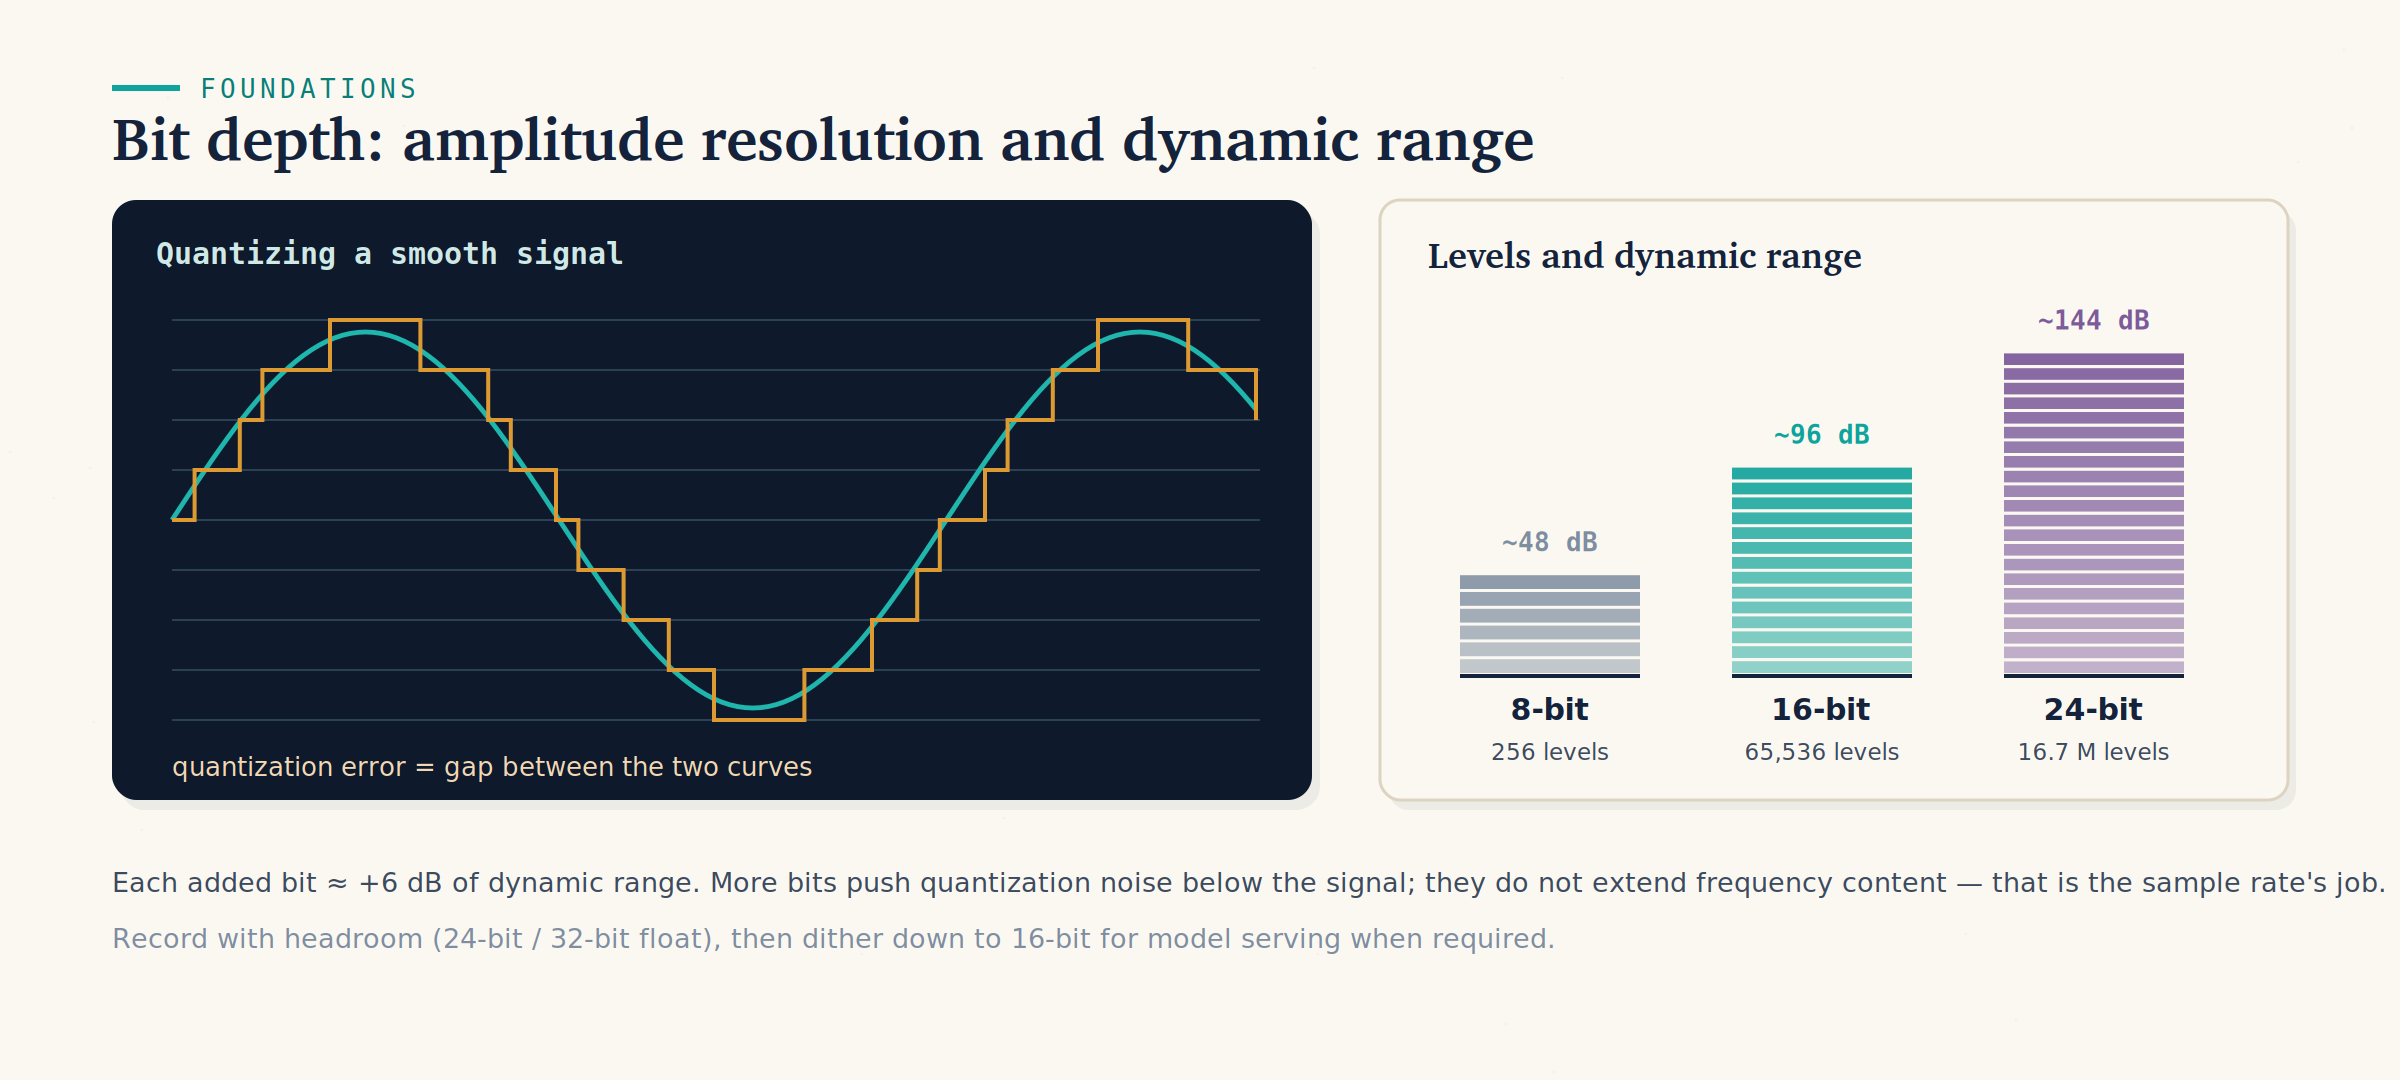

<sub><i>Bit depth sets amplitude resolution. ~6 dB dynamic range per bit; it does not add bandwidth.</i></sub>

Rounding each sample to a finite set of levels injects *quantization noise*;
SNR improves ~**6 dB per bit**.

Quantizing to 2 bits -> 4 levels
Available quantization levels:
[-1.         -0.33333333  0.33333333  1.        ]

Signal:  [-1.  -0.6  0.   0.2  0.9]
Quantizing to 2 bits -> 4 levels
Final quantized values: [-1.         -0.33333333  0.33333333  0.33333333  1.        ]






Quantizing to 3 bits -> 8 levels
Available quantization levels:
[-1.         -0.71428571 -0.42857143 -0.14285714  0.14285714  0.42857143
  0.71428571  1.        ]

Signal:  [-1.  -0.6  0.   0.2  0.9]
Quantizing to 3 bits -> 8 levels
Final quantized values: [-1.         -0.71428571  0.14285714  0.14285714  1.        ]






Signal:  [-1.  -0.6  0.   0.2  0.9]
Quantizing to 8 bits -> 256 levels
Final quantized values: [-1.         -0.6         0.00392157  0.2         0.89803922]








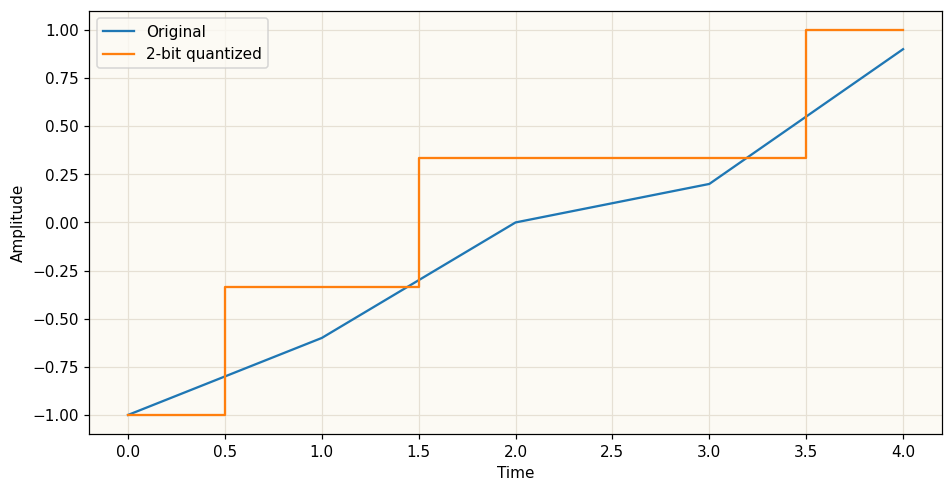

In [23]:
import numpy as np
import matplotlib.pyplot as plt

def quantize(sig, bits):
    levels = 2 ** bits
    if bits <=3 :

      # These are the actual amplitude values that the signal is allowed to snap to
      quantization_levels = np.linspace(-1, 1, levels)

      print(f"Quantizing to {bits} bits -> {levels} levels")
      print(f"Available quantization levels:")
      print(quantization_levels)
      print()

    if len(sig) <= 10:
      print("Signal: ", sig)
    print(f"Quantizing to {bits} bits -> {levels} levels")
    sig = np.clip(sig, -1, 1)
    # print(f"Signal clipped to [-1, 1], original {sig} -> clipped {sig}")
    sig_01 = (sig + 1) / 2
    # print(f"Signal scaled to [0, 1], original {sig_01} -> scaled {sig_01}")
    scaled = sig_01 * (levels - 1)
    # print(f"Signal scaled to [0, {levels - 1}], original {scaled} -> scaled {scaled}")
    rounded = np.round(scaled)
    # print(f"Rounded values: {rounded}")
    quantized = (rounded / (levels - 1)) * 2 - 1
    print(f"Final quantized values: {quantized}")
    print('\n' * 3, "===" * 20, '\n' * 3)
    return quantized

# create a smooth sine wave
#t = np.linspace(0, 1, 500)
#sig = np.sin(2 * np.pi * 5 * t)

sig = np.array([-1.0, -0.6, 0.0, 0.2, 0.9])
t = np.arange(len(sig))  # adjust time vector to match sig length

# quantize it
q2 = quantize(sig, bits=2)
q3 = quantize(sig, bits=3)
q8 = quantize(sig, bits=8)

plt.figure(figsize=(10, 5))

plt.plot(t, sig, label="Original")
plt.step(t, q2, label="2-bit quantized", where="mid")

plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.show()

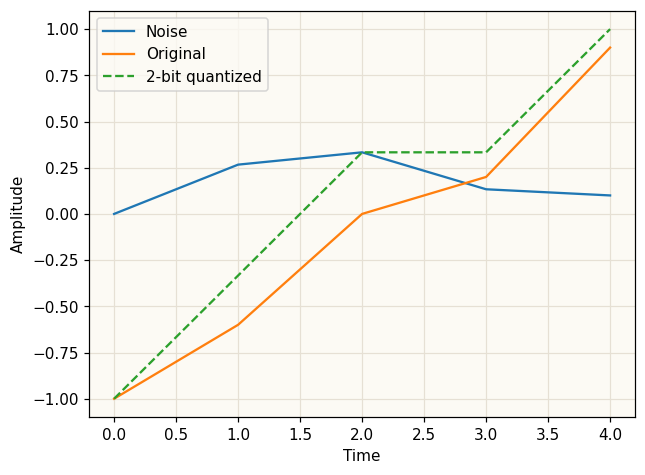

In [24]:
noise = q2 - sig

plt.plot(t, noise, label="Noise")
plt.plot(t, sig, label="Original")
plt.plot(t, q2, label="2-bit quantized", linestyle='--')
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.show()

In [25]:
# Quantize the real speech clip (y16, from §1) to fewer and fewer bits and
# listen to the noise floor rise. SNR climbs ~6 dB per bit, just as promised.
import numpy as np
from IPython.display import Audio, display

def quantize(sig, bits):
    levels = 2 ** bits
    s = np.clip(sig, -1, 1)
    s = (s + 1) / 2 * (levels - 1)             # map [-1, 1] -> [0, levels-1]
    return (np.round(s) / (levels - 1)) * 2 - 1  # snap to nearest rung, map back

print("original (float32, ~transparent):"); display(Audio(y16, rate=SR))
print(f"{'bits':>4} {'levels':>8} {'SNR(dB)':>8}")
for b in [16, 8, 4, 2]:
    q = quantize(y16, b)
    snr = 20 * np.log10(np.linalg.norm(y16) / (np.linalg.norm(y16 - q) + 1e-12))
    print(f"{b:>4} {2 ** b:>8} {snr:>8.1f}")
    display(Audio(q, rate=SR))

original (float32, ~transparent):


bits   levels  SNR(dB)
  16    65536     72.5


   8      256     27.8


   4       16      2.0


   2        4    -13.7


#### 💡 Knowledge Check: Bit depth
**Q: You requantize audio from 16-bit down to 12-bit. Using the ~6 dB-per-bit rule of thumb, roughly how much signal-to-noise ratio do you lose?**

A) 6 dB  
B) 12 dB  
C) 24 dB  
D) 48 dB  

**Correct Answer: C**  
*Explanation: You dropped 4 bits and each bit is worth ~6 dB of SNR, so 4 × 6 ≈ 24 dB. Sample rate is untouched — only amplitude resolution changed.*

## 2 · Loading audio without shooting yourself in the foot (≈15 min)

This is the section that saves you days of debugging. Five things go wrong in
production, in roughly this order of frequency:

1. **Sample-rate mismatch (the big one).** You load a 44.1 kHz podcast and pass
   `sampling_rate=16000` to the model, *or* you resample but forget to tell the
   model. Either way the audio is silently misinterpreted. **Rule: resample to
   the model's rate AND pass that same rate everywhere.**
2. **Stereo vs mono.** Files are often 2-channel `(samples, 2)`; models want
   mono `(samples,)`. Average the channels — don't just drop one.
3. **int16 vs float.** WAV stores `int16` in [-32768, 32767]; models want
   `float32` in [-1, 1]. `librosa.load` / `soundfile(dtype="float32")` handle
   this; raw `np.frombuffer` does not.
4. **Format / codec.** `.wav` is trivial; `.mp3/.m4a/.webm` need a decoder
   (ffmpeg). The `torchcodec` path in new `datasets` is the usual culprit —
   decode bytes with `soundfile` instead.
5. **Clipping / normalization.** Values outside [-1, 1] clip to harsh
   distortion; loud-normalize toward ~-1 dBFS when you concatenate clips.

Let's *hear* the #1 bug — hearing it is what makes it stick.

In [26]:
# Our clip is 16 kHz. Watch what "the same array" sounds like when we LIE
# about its sample rate -- this is the mismatch bug, made audible.
from IPython.display import Audio, display

print("CORRECT  -- player told the true rate (", SR, "Hz):")
display(Audio(y16, rate=SR))

print("'chipmunk' -- claimed 24 kHz for 16 kHz audio (1.5x too fast):")
display(Audio(y16, rate=int(SR * 1.5)))

print("'slow-mo'  -- claimed ~10.7 kHz (0.67x too slow):")
display(Audio(y16, rate=int(SR * 0.67)))

# Passing the wrong sampling_rate= to a feature extractor does exactly this to
# the model's INPUT, except you can't hear it -- you just get wrong transcripts.

CORRECT  -- player told the true rate ( 16000 Hz):


'chipmunk' -- claimed 24 kHz for 16 kHz audio (1.5x too fast):


'slow-mo'  -- claimed ~10.7 kHz (0.67x too slow):


In [27]:
# The correct preparation, step by step, on a stereo 44.1 kHz example
# (real files arrive like this constantly).
fake_sr = 44_100
stereo = np.stack([                                       # shape (n, 2)
    librosa.resample(y16, orig_sr=SR, target_sr=fake_sr),
    librosa.resample(y16, orig_sr=SR, target_sr=fake_sr),
], axis=1)
print("arrived as:", stereo.shape, stereo.dtype, "@", fake_sr, "Hz")

# 1) STEREO -> MONO: average the channels (don't just drop one).
mono = stereo.mean(axis=1)
print("to mono   :", mono.shape)

# 2) ensure float32 in [-1, 1] (loaders with dtype=float32 already give this).
mono = mono.astype(np.float32)
print("dtype     :", mono.dtype, "range [%.2f, %.2f]" % (mono.min(), mono.max()))

# 3) RESAMPLE to the model's rate
ready = librosa.resample(mono, orig_sr=fake_sr, target_sr=SR)
print("to 16 kHz :", ready.shape, "@", SR, "Hz  <- model-ready")

# In production these three lines live in one prepare(wav, sr) helper.

arrived as: (258206, 2) float32 @ 44100 Hz
to mono   : (258206,)
dtype     : float32 range [-0.35, 0.43]
to 16 kHz : (93681,) @ 16000 Hz  <- model-ready


### Why `librosa.resample`, not `wav[::k]`?

Dropping every k-th sample (`wav[::2]`) skips the **anti-alias filter**.
Frequencies above the new limit don't vanish — they *fold back* as a metallic,
false low-frequency buzz (**aliasing**). You'll basically never write this by
hand, but you should recognize the sound, because a mis-built resampling step
produces exactly it.

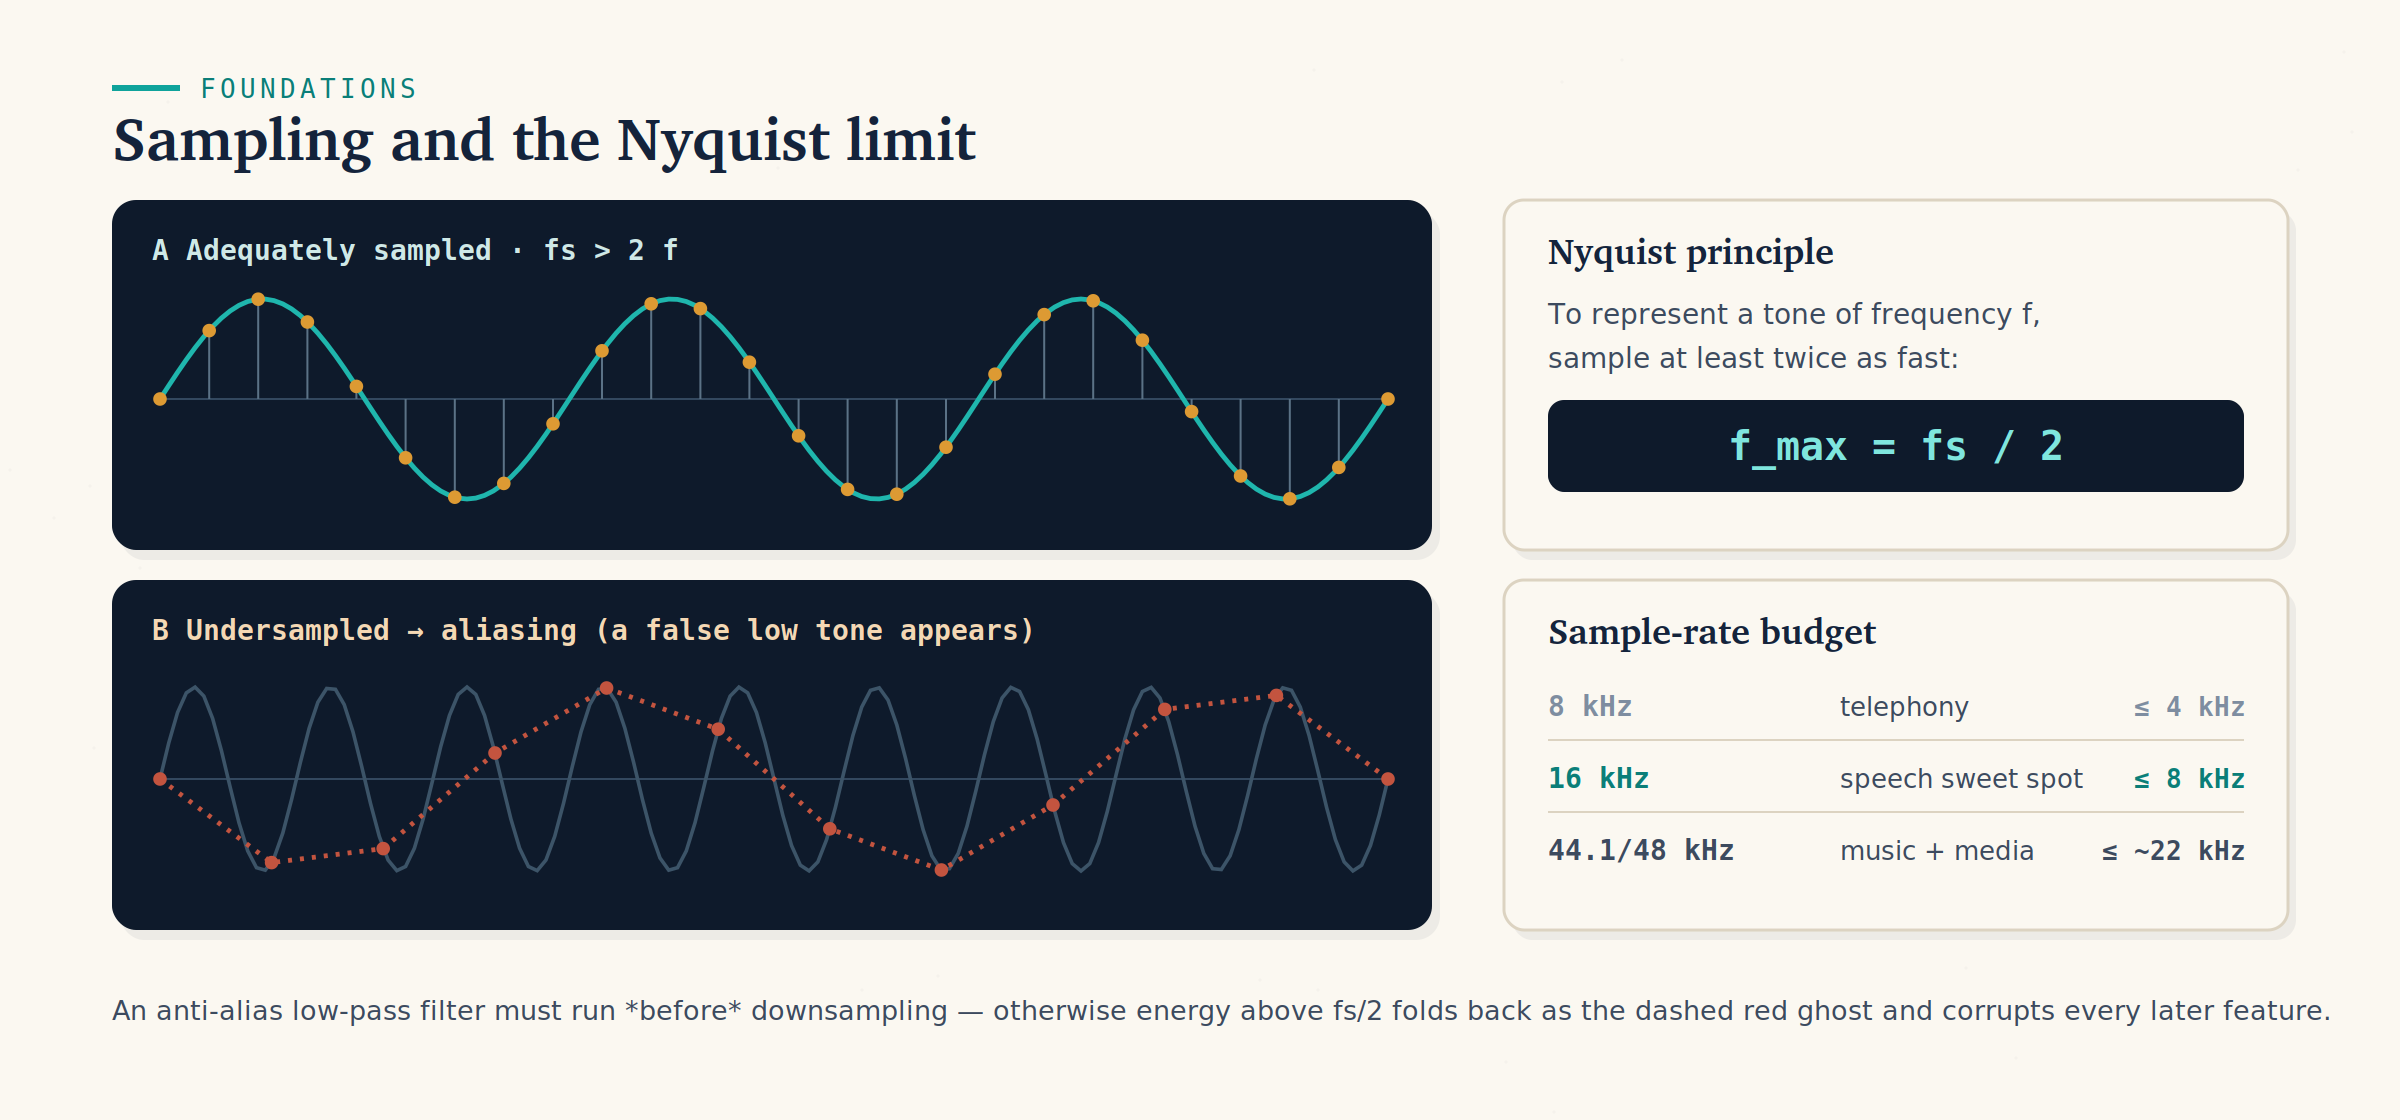
<sub><i>Enough samples reconstruct the tone; too few fold a high tone down into a permanent false low one (red). The fix is a low-pass filter <b>before</b> dropping samples — which <code>librosa.resample</code> does for you.</i></sub>

In [28]:
# Hear the difference at the SAME output rate, so the ONLY variable is the
# anti-alias filter. (You won't code this in prod -- just learn the sound.)
factor = 2
target = SR // factor

clean = librosa.resample(y16, orig_sr=SR, target_sr=target)  # filter THEN drop
alias = y16[::factor]                                         # just drop -> aliasing

print("clean (anti-aliased -- duller but correct):")
display(Audio(clean, rate=target))
print("naive y[::2] (same rate, harsh/metallic aliasing -- this is a BUG):")
display(Audio(alias, rate=target))

clean (anti-aliased -- duller but correct):


naive y[::2] (same rate, harsh/metallic aliasing -- this is a BUG):


#### 💡 Knowledge Check: Loading footguns
**Q: All of the following silently corrupt the audio a model sees, EXCEPT:**

A) Passing `sampling_rate=16000` for a 44.1 kHz file  
B) Feeding a `(samples, 2)` stereo array to a mono model  
C) Storing the waveform as float32 in the range [-1, 1]  
D) Downsampling with `wav[::2]` instead of a resampler  

**Correct Answer: C**  
*Explanation: float32 in [-1, 1] is exactly what models expect — that one is correct. The other three (rate mismatch, stereo into a mono model, slice-instead-of-resample) are the classic silent corruptions.*

## 3 · What the model actually sees: the spectrogram (≈10 min)

Models almost never read the raw waveform — 16,000 numbers/second is too much
and too low-level. The front-end first converts the wave into a **spectrogram**:
a picture of *which frequencies are present, over time*.

You do **not** need the Fourier math. The intuition is enough:

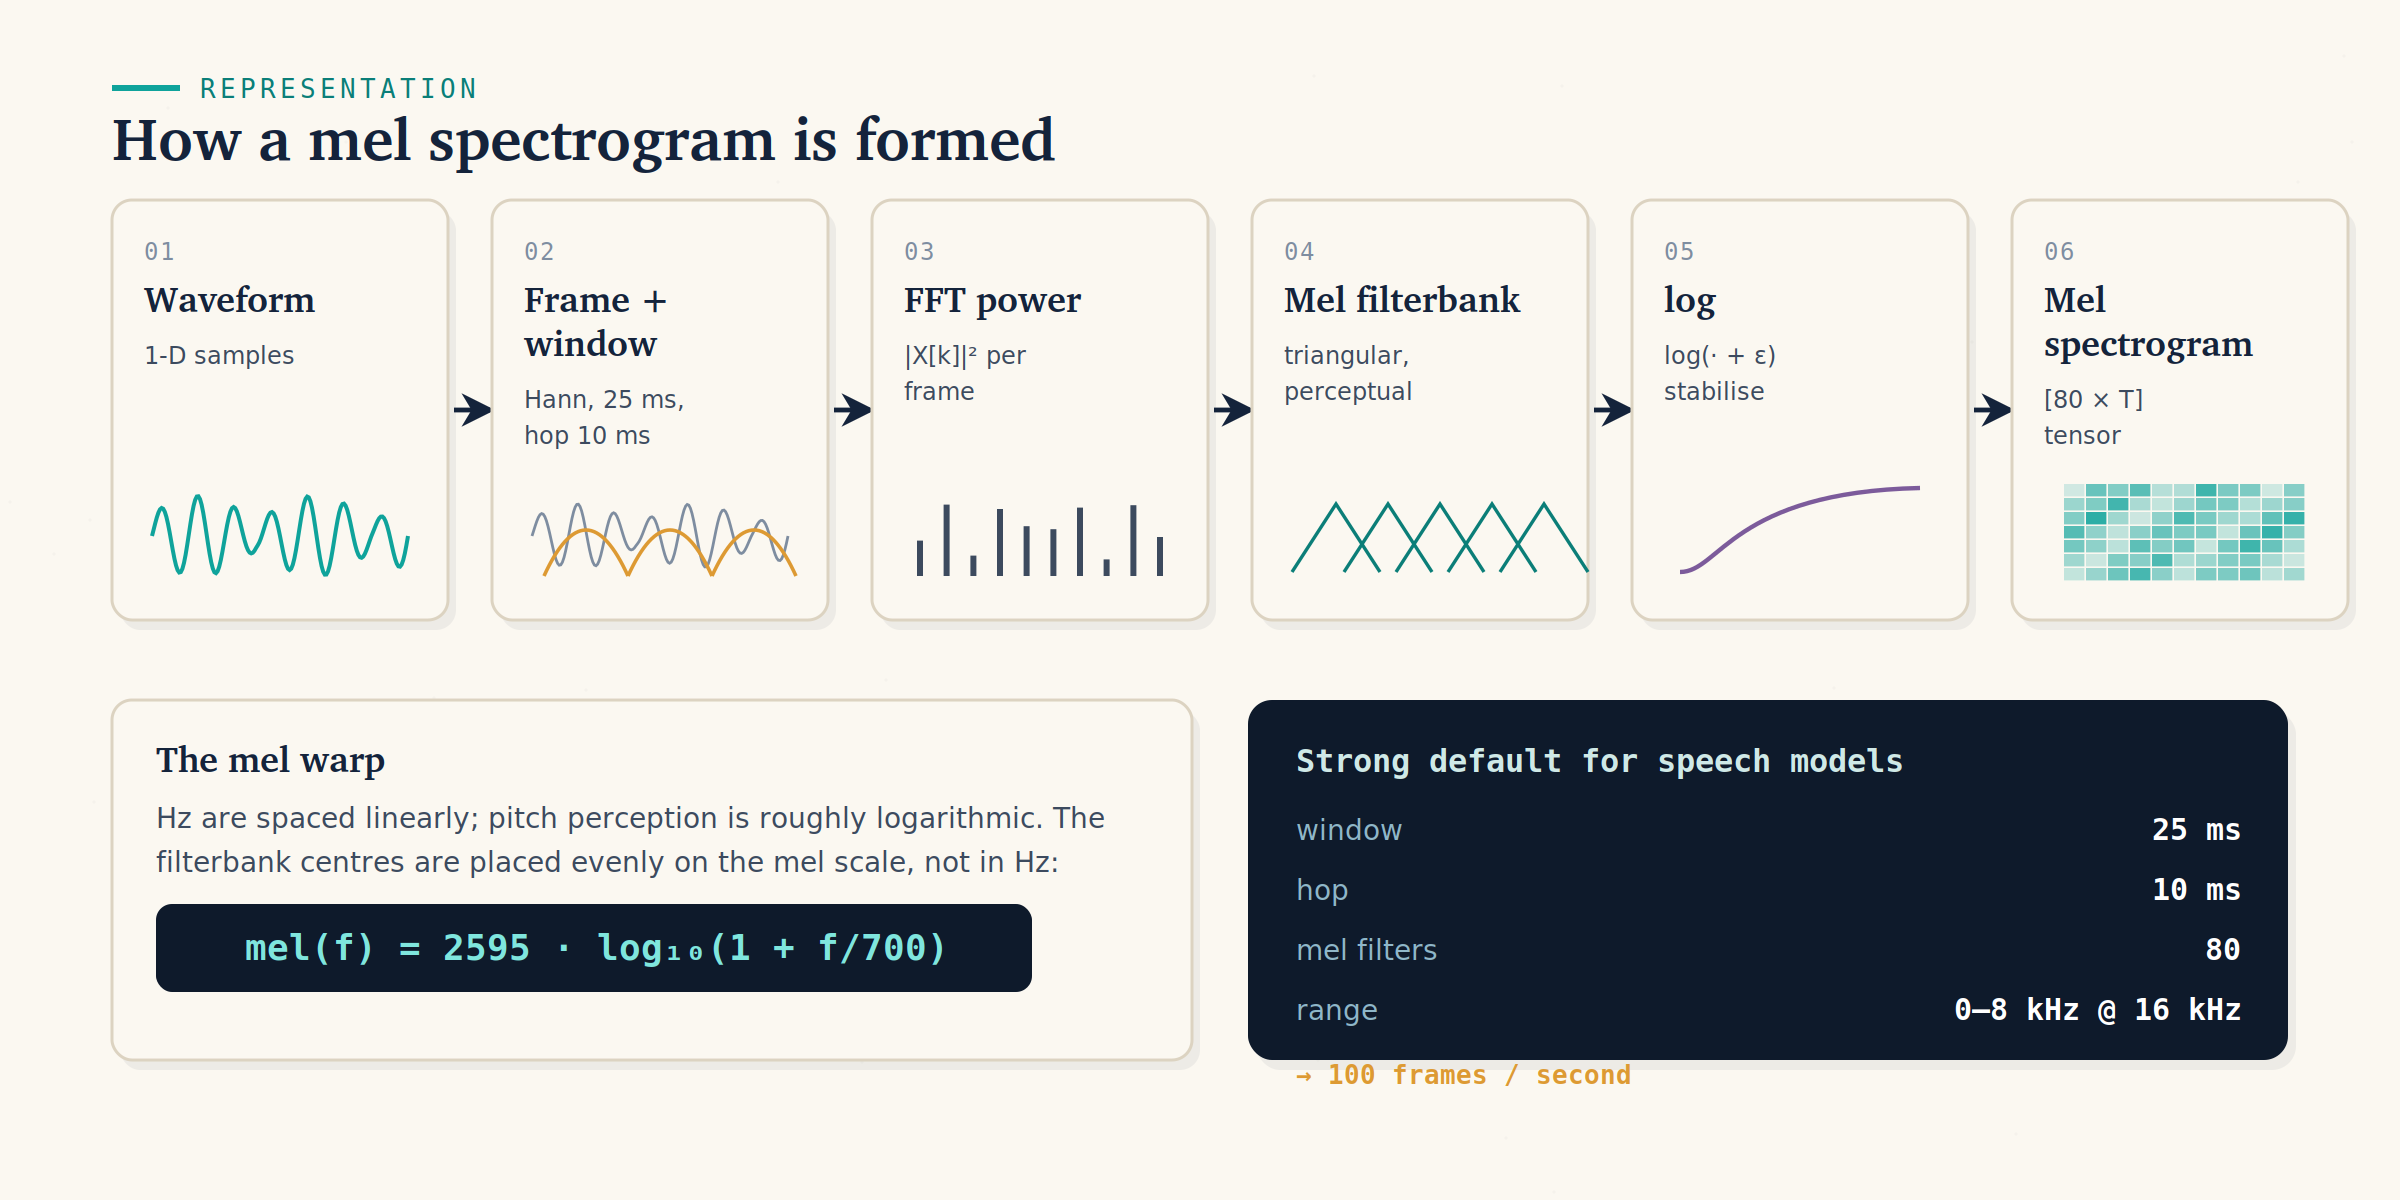
<sub><i>Slide a short window along the audio, ask "what frequencies are in this window?", stack the answers as columns. That image is the spectrogram.</i></sub>

Two refinements turn a raw spectrogram into the **log-mel spectrogram** every
speech model eats:

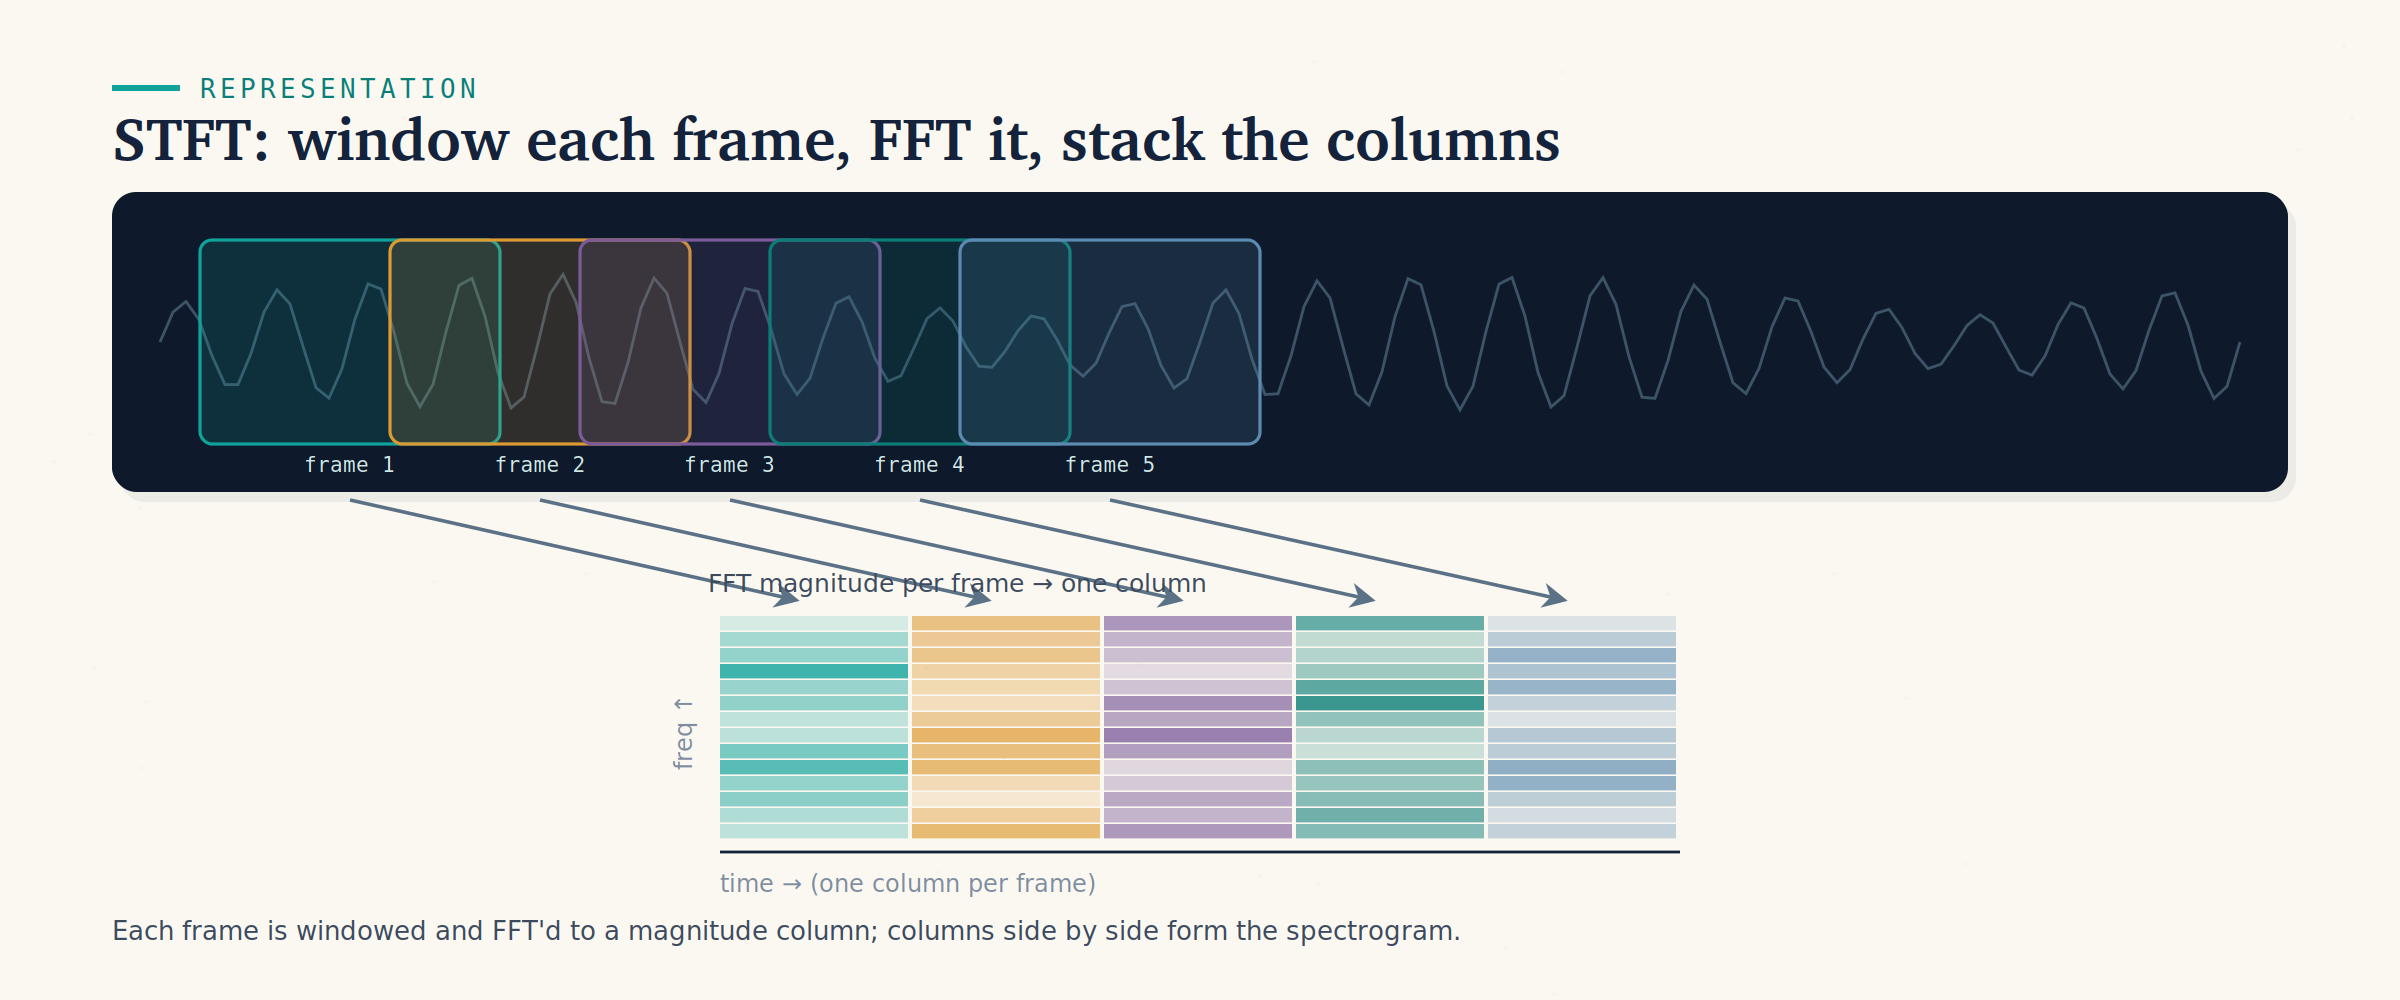
<sub><i><b>Step 1 (STFT):</b> each short overlapping window becomes one vertical column of frequency energy.</i></sub>

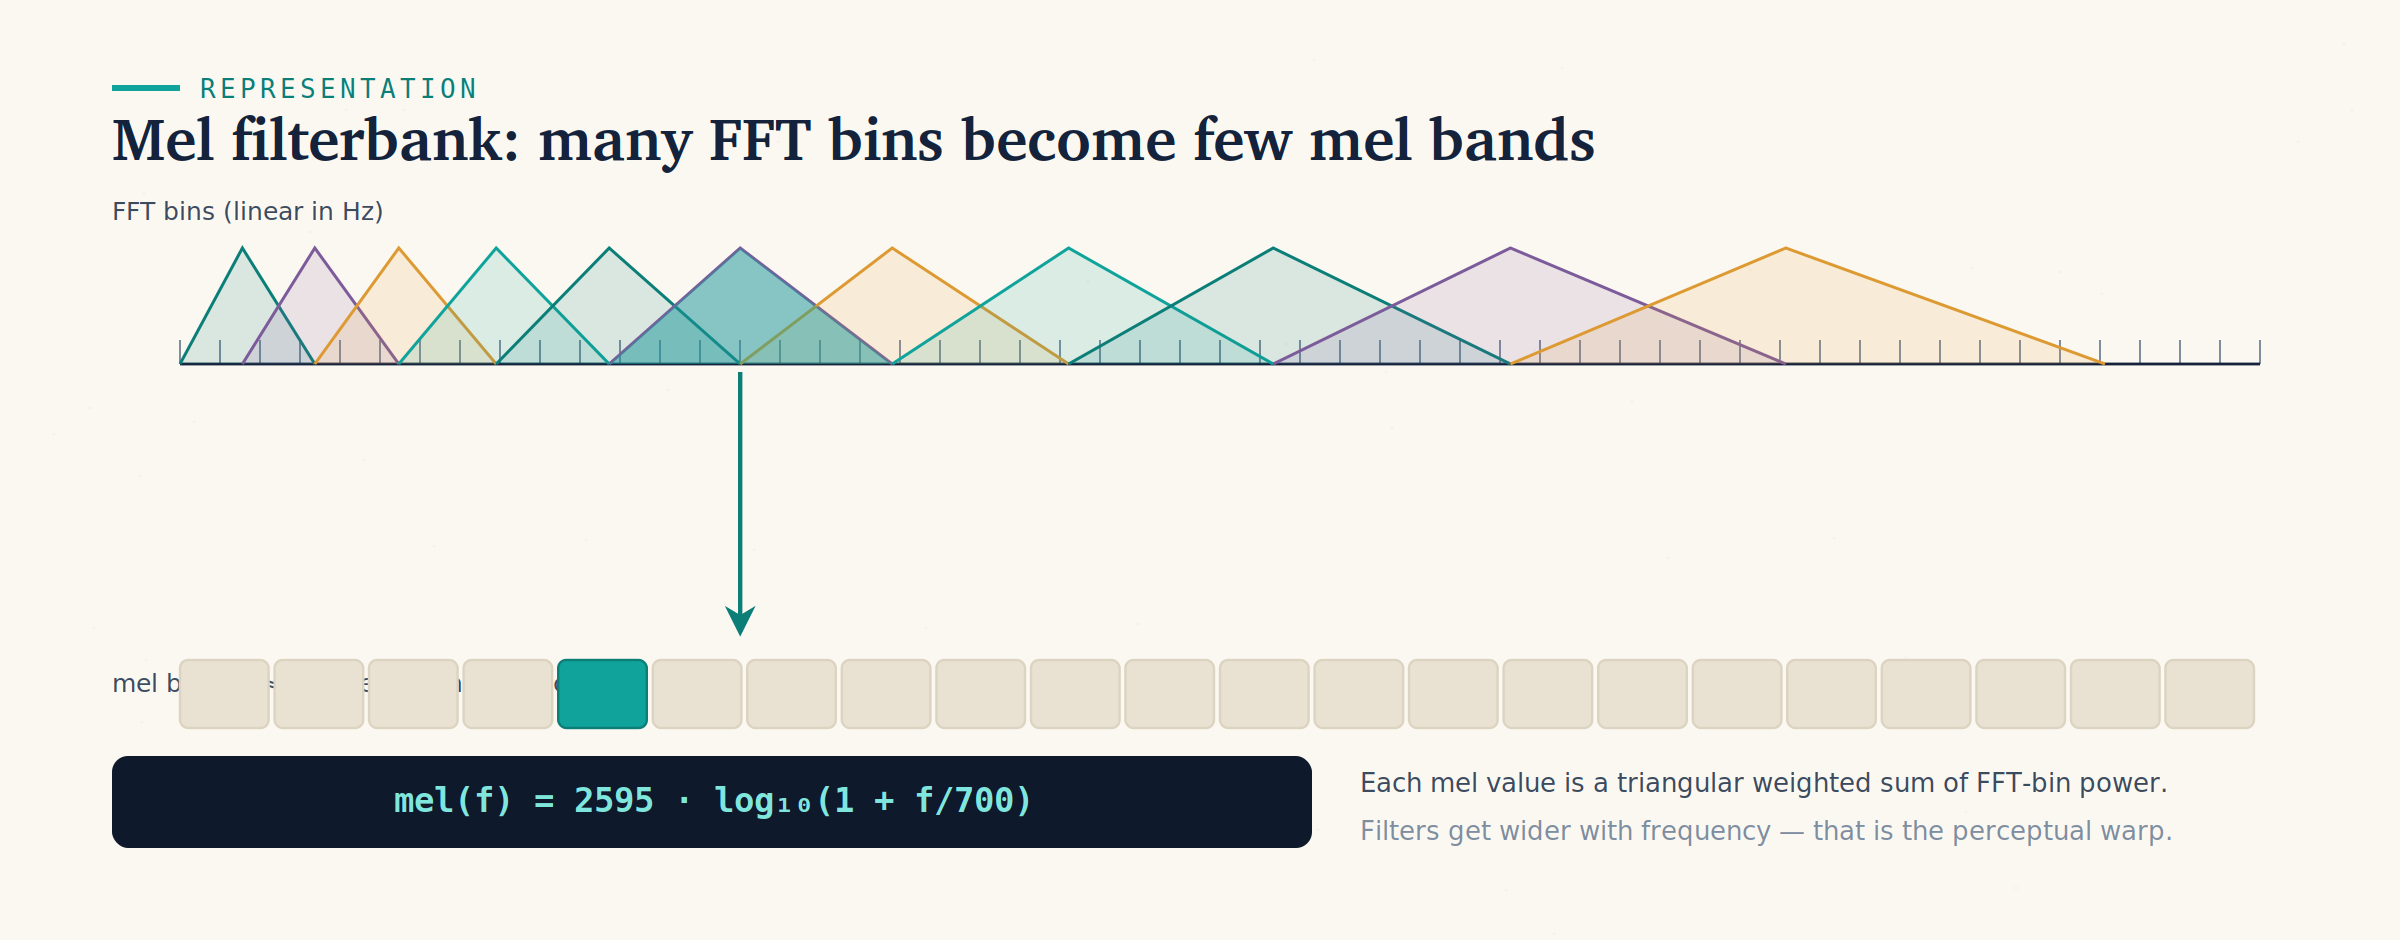
<sub><i><b>Step 2 (mel + log):</b> squash the many FFT bins into ~80 perceptual "mel" bands (fine at low freq, coarse at high — like human hearing), then take a log so quiet detail survives.</i></sub>

The canonical speech config — **25 ms window / 10 ms hop / 80 mel bands /
0–8 kHz @ 16 kHz** — produces exactly **100 columns per second**. That is
literally what Whisper's feature extractor outputs. You rarely touch these
numbers; you just need to know the output is an `(80, T)` image.

In [ ]:
# raw audio waveform
#         ↓
# short overlapping frames
#         ↓
# frequency-energy analysis
#         ↓
# mel frequency compression

#         ↓
# log-mel spectrogram
#         ↓
# speech model encoder

Mel is a frequency scale designed to roughly match human hearing.


Humans do not perceive frequency linearly. The difference between 100 Hz and 200 Hz feels much bigger than the difference between 7100 Hz and 7200 Hz.

mel spectrogram = spectrogram compressed into human-hearing-friendly frequency bands

log-mel shape: (80, 586) = (mel bands, time frames)
frames/sec   : 100  (~100, as promised)


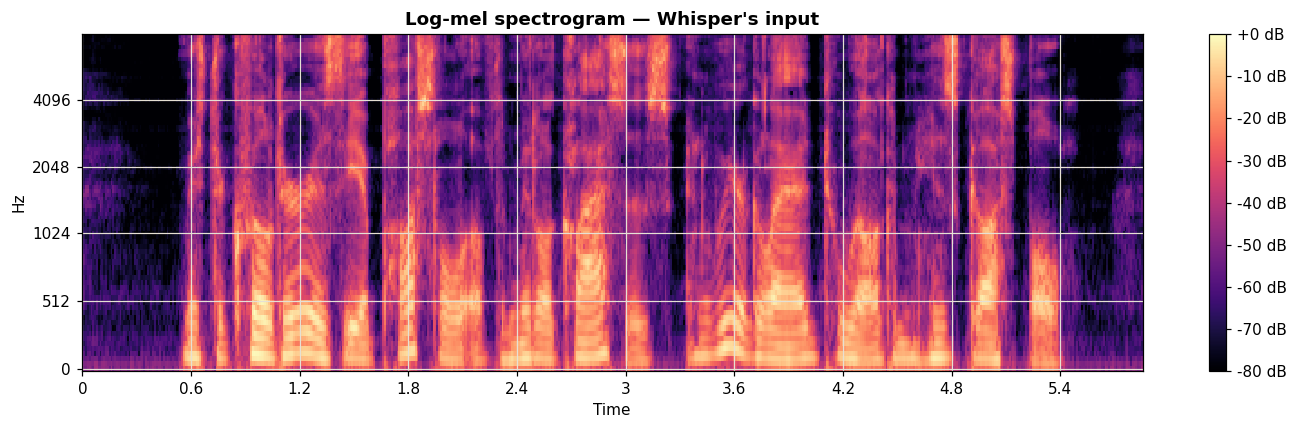

as a model tensor: (1, 80, 586) (batch, 80 mel, frames)


In [30]:
import librosa.display

# Whisper-style front-end settings (you almost never change these).
n_mels,  hop, win = 80, 160, 400   # 400=25ms, 160=10ms at 16 kHz

mel = librosa.feature.melspectrogram(
    y=y16, sr=SR,  hop_length=hop, win_length=win,
    n_mels=n_mels, fmin=0, fmax=8000, power=2.0)    # power spectrogram
log_mel = librosa.power_to_db(mel, ref=np.max)      # the "log" step (in dB)

print("log-mel shape:", log_mel.shape, "= (mel bands, time frames)")
print(f"frames/sec   : {log_mel.shape[1] / (len(y16)/SR):.0f}  (~100, as promised)")

plt.figure(figsize=(13, 4))
librosa.display.specshow(log_mel, sr=SR, hop_length=hop,
                         x_axis="time", y_axis="mel", fmax=8000, cmap="magma")
plt.colorbar(format="%+2.0f dB"); plt.title("Log-mel spectrogram — Whisper's input")
plt.tight_layout(); plt.show()

# This (80, T) image is ALL the encoder reads. As a tensor it's just:
#   (batch, mel, time)  ==  log_mel[None, :, :]
print("as a model tensor:", (1,) + log_mel.shape, "(batch, 80 mel, frames)")

**The one front-end knob worth knowing: window length.** A *short* window
pins down *when* a sound happened but smears *which* frequency it was; a *long*
window does the reverse. 25 ms is the speech compromise — long enough to read
pitch, short enough to catch fast consonants. You'll basically never change it,
but this is why "more time detail" and "more frequency detail" trade off.

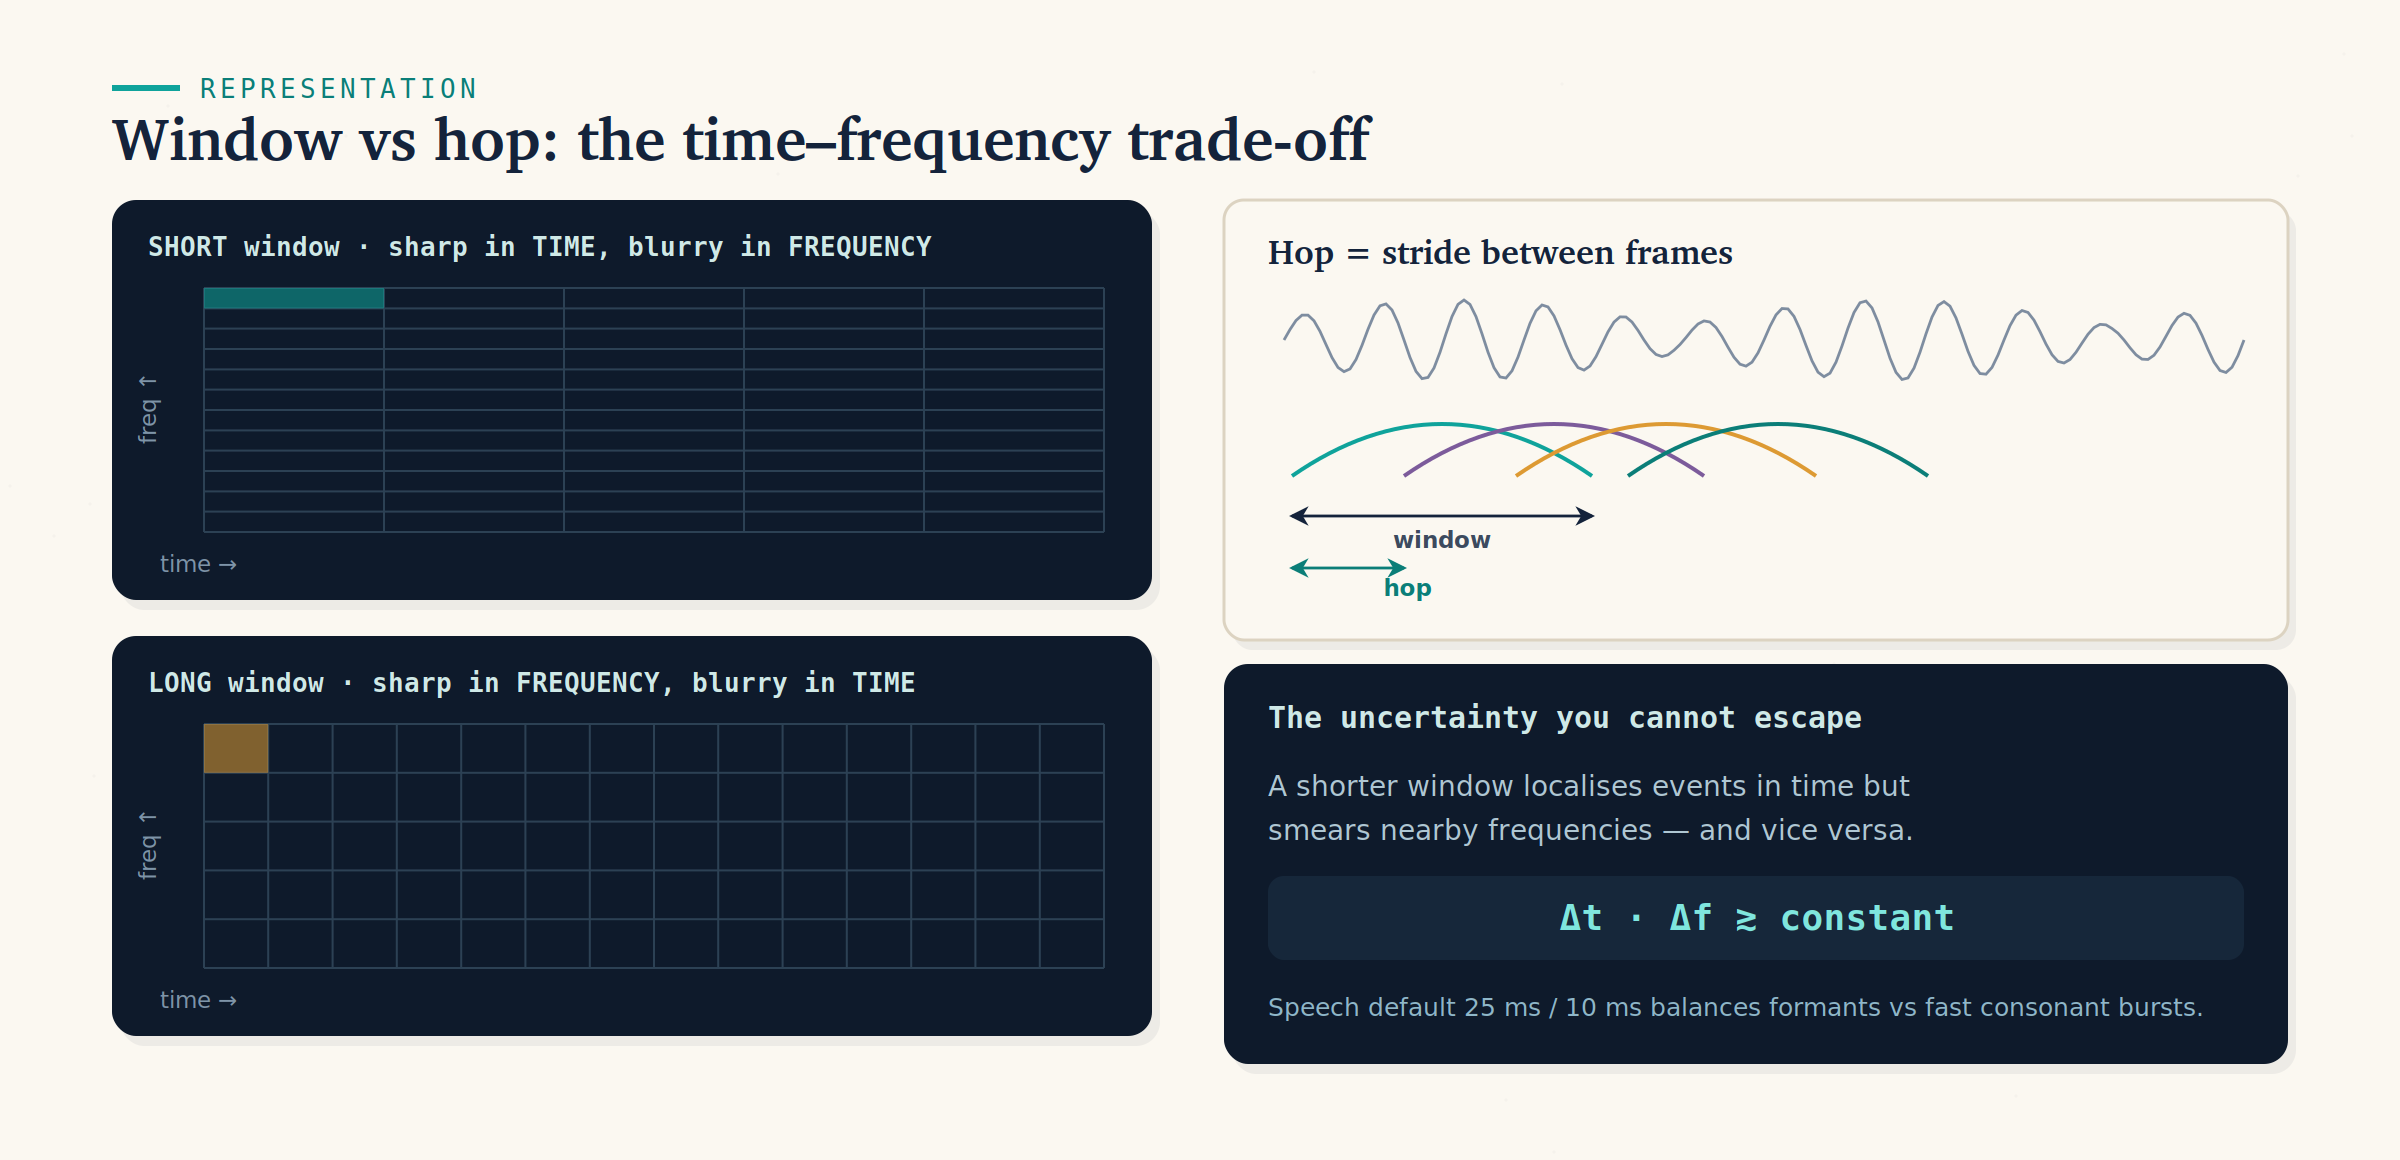
<sub><i>Short window: sharp in time, blurry in frequency. Long window: the reverse. 25 ms is the speech sweet spot.</i></sub>

#### 💡 Knowledge Check: Window length
**Q: You shorten the STFT analysis window from 25 ms down to 5 ms. What is the trade-off?**

A) Better time resolution, worse frequency resolution  
B) Better frequency resolution, worse time resolution  
C) Better resolution on both axes  
D) Worse resolution on both axes  

**Correct Answer: A**  
*Explanation: A short window pins down when a sound happened but smears which frequency it was. You cannot sharpen both axes at once — that is the core STFT trade-off.*

## 4 · Speech recognition with Whisper (≈25 min)

**Whisper** is the workhorse: a Transformer **encoder–decoder** over the log-mel
image from §3. The encoder reads the whole spectrogram; the decoder writes text
one token at a time, attending back to the audio.

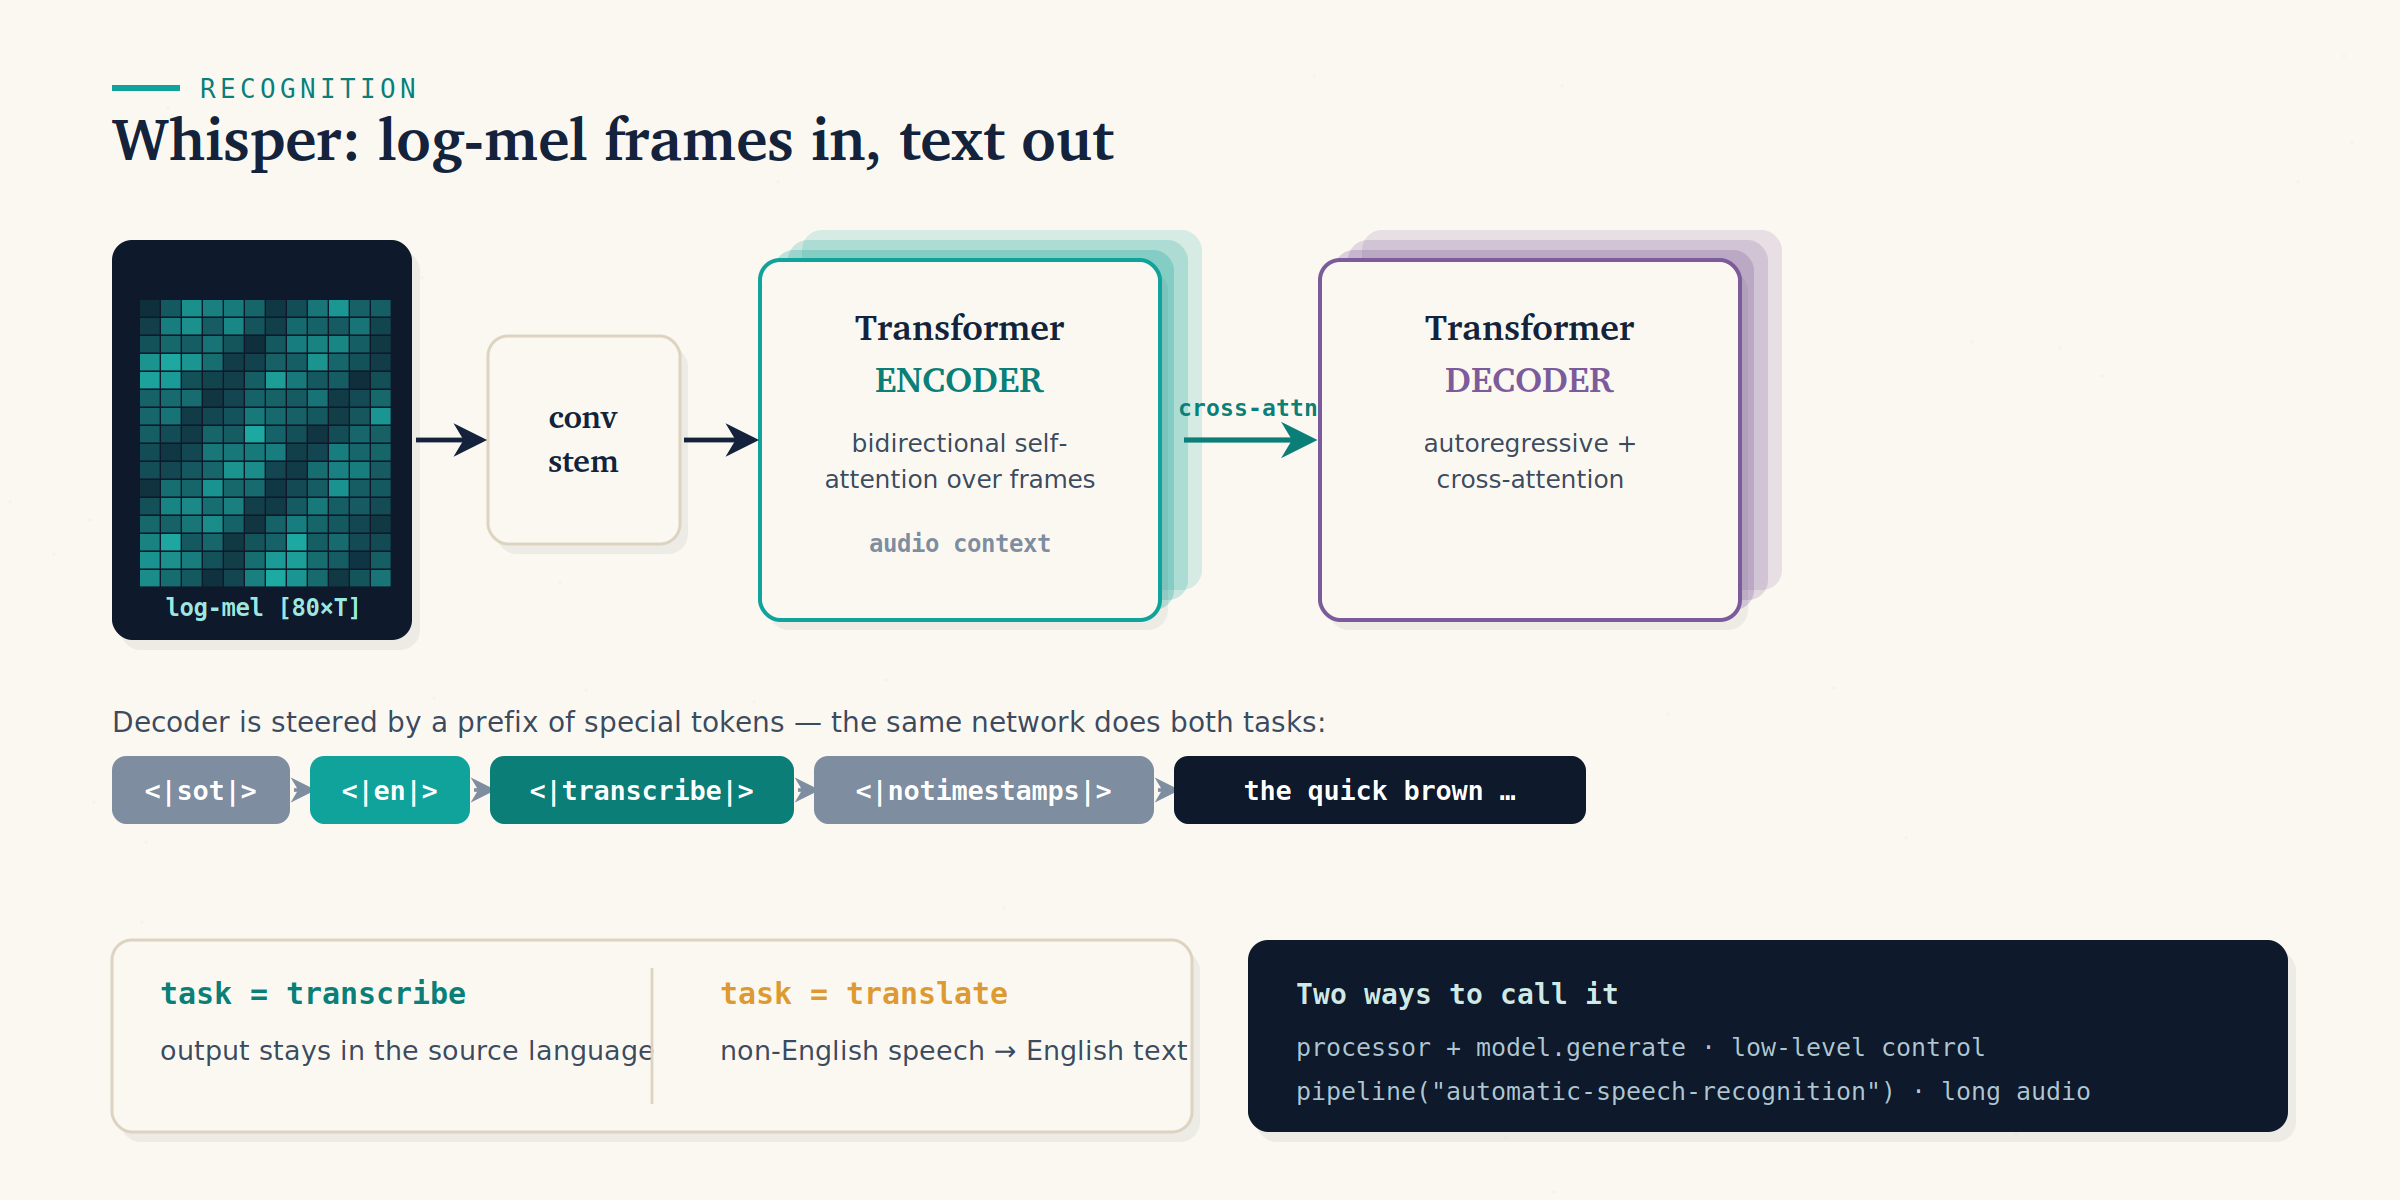
<sub><i>Encoder reads the 80-band log-mel; decoder emits text tokens. A special-token prefix steers the <b>same weights</b> between transcribe and translate.</i></sub>

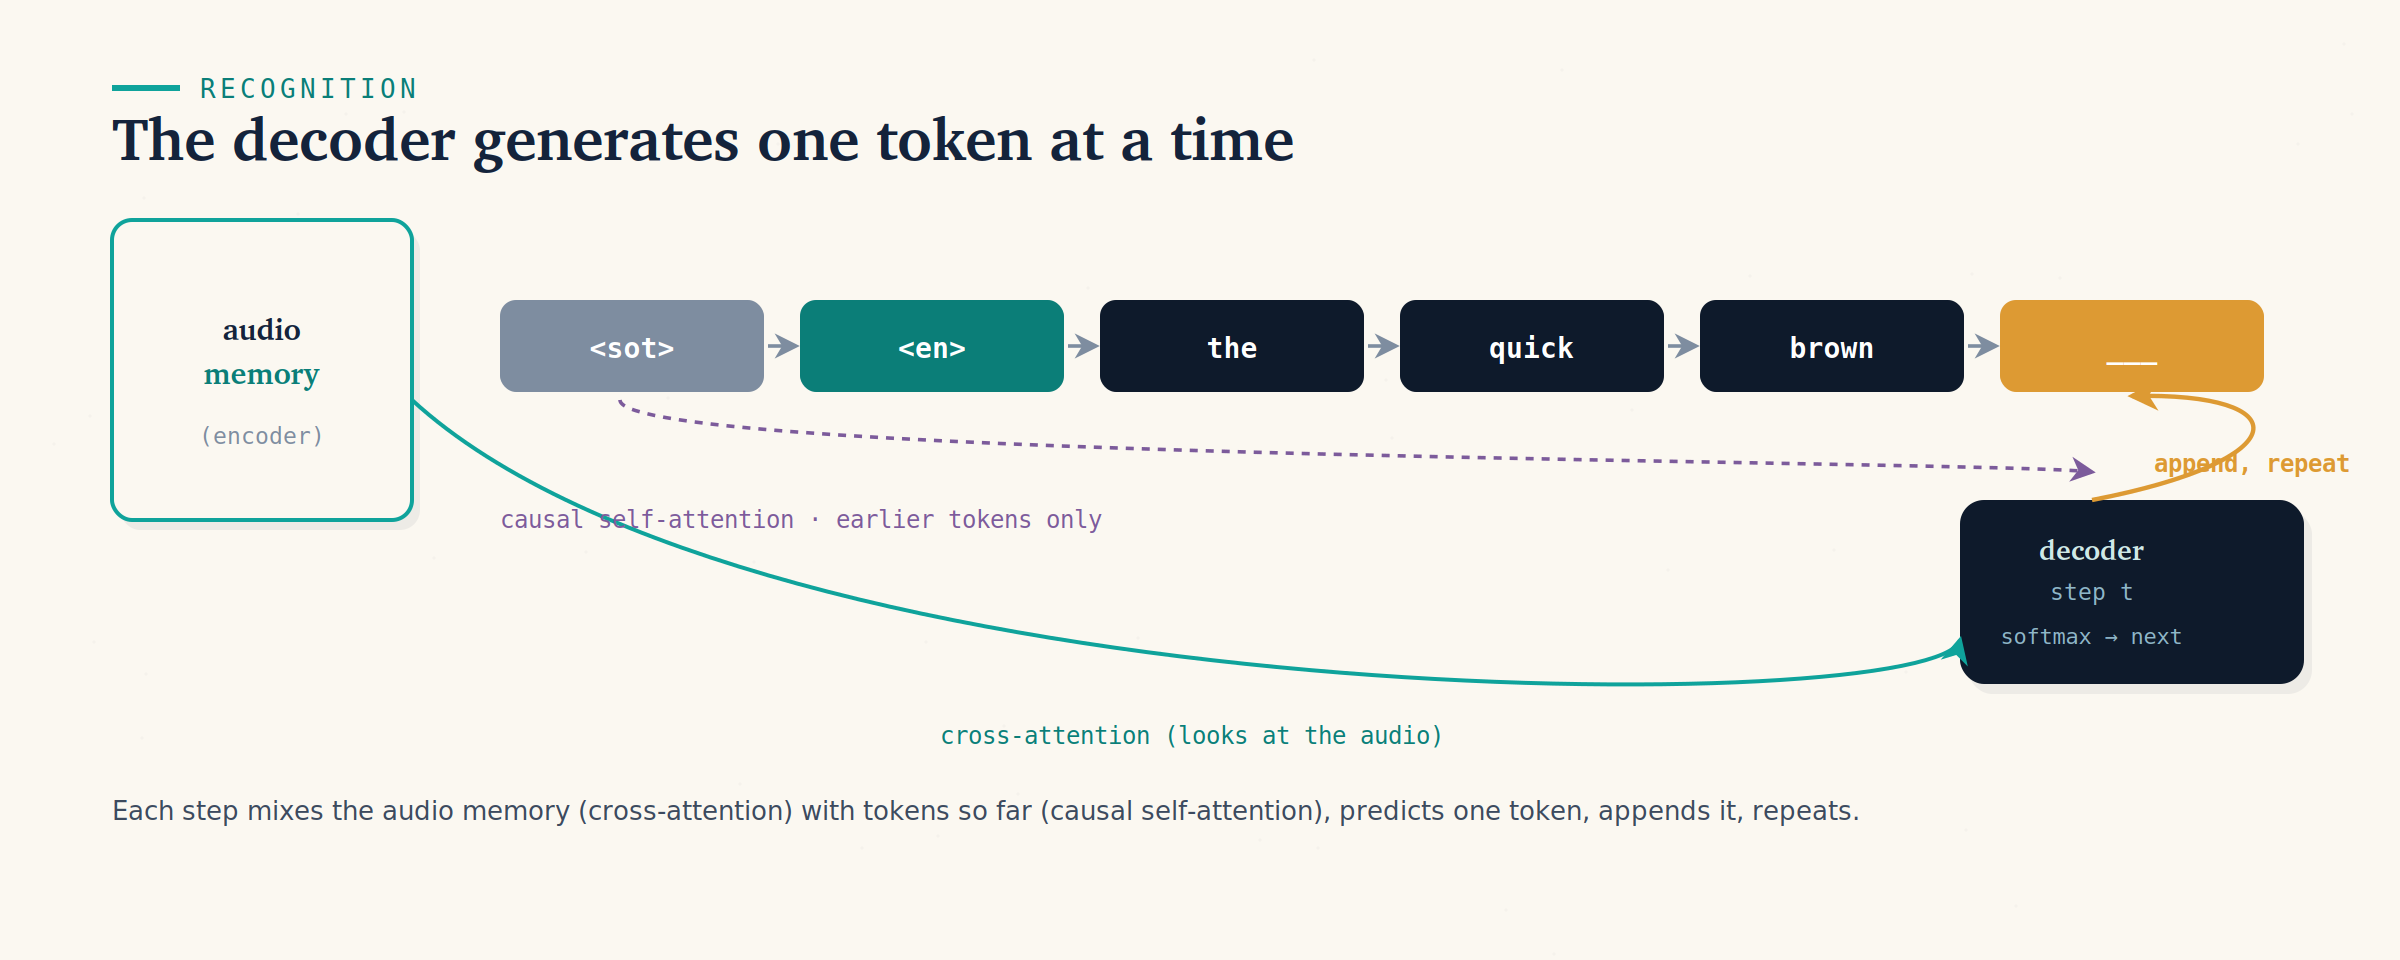
<sub><i>Autoregressive decoding: each step reads the audio (cross-attention) + the tokens so far (causal self-attention), predicts the next token, appends, repeats.</i></sub>

The thing to internalize: **Whisper's task is set by a token prefix**, not a
different model. `<|startoftranscript|><|en|><|transcribe|>` vs `…<|translate|>`
is the only difference between transcription and translation.

In [31]:
# Load Whisper, guarded. Defines _ASR_READY, processor, model, hyp for below.
_ASR_READY = False
processor = model = hyp = None
if HF_OK and TORCH_OK:
    try:
        from transformers import WhisperProcessor, WhisperForConditionalGeneration
        processor = WhisperProcessor.from_pretrained(ASR_MODEL_ID)
        model = WhisperForConditionalGeneration.from_pretrained(
            ASR_MODEL_ID).to(device).eval()
        _ASR_READY = True
        n = sum(p.numel() for p in model.parameters()) / 1e6
        print(f"loaded {ASR_MODEL_ID}  (~{n:.0f}M params) on {device}")
    except Exception as e:
        print("ASR model not loaded (", type(e).__name__, "). Re-run with network.")
else:
    print("[skipped] transformers/torch unavailable. §4+ print notices; §1-§3 are real.")

Loading weights:   0%|          | 0/245 [00:00<?, ?it/s]

loaded openai/whisper-base.en  (~73M params) on mps


In [32]:
# Transcribe our 16 kHz clip. NOTE sampling_rate=16_000 -- this MUST match the
# audio's true rate (the §2 mismatch footgun, made concrete right here).
if _ASR_READY:
    feats = processor(y16, sampling_rate=16_000,
                      return_tensors="pt").input_features.to(device)
    print("input_features:", tuple(feats.shape), "= (batch, 80 mel, frames)")
    with torch.no_grad():
        ids = model.generate(feats, max_new_tokens=128)
    hyp = processor.batch_decode(ids, skip_special_tokens=True)[0].strip()
    print("\nhypothesis:", hyp)
    print("reference :", ref_text)
else:
    print("[skipped] needs Whisper. Expected: decoded transcript vs the reference.")

Using custom `forced_decoder_ids` from the (generation) config. This is deprecated in favor of the `task` and `language` flags/config options.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


input_features: (1, 80, 3000) = (batch, 80 mel, frames)


Both `max_new_tokens` (=128) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see related `.generate()` flags.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_pr


hypothesis: Mr. Quilter is the apostle of the middle classes, and we are glad to welcome his gospel.
reference : MISTER QUILTER IS THE APOSTLE OF THE MIDDLE CLASSES AND WE ARE GLAD TO WELCOME HIS GOSPEL


### The knobs you'll actually twist

| Knob | What it does | Production guidance |
|---|---|---|
| **model size** | `tiny` → `large-v3-turbo` | start at `large-v3-turbo`: near-`large` accuracy, ~6–8× faster. Use `*.en` models only for English. |
| **`language`** | skip auto-detect | **always set it if you know it.** Auto-detect is a common failure on short/noisy clips. |
| **`task`** | `transcribe` / `translate` | `translate` = speech → **English** text from any source language. |
| **`return_timestamps`** | per-segment times | needed for subtitles, diarization alignment, long audio. |
| **`temperature`** | sampling randomness | keep `0`. Whisper uses a temperature *fallback* (0→0.2→…) only when decoding looks degenerate. |
| **`condition_on_previous_text`** | feed prior text as context | helps fluency but **propagates hallucinations** — turn off if you see runaway repeats. |
| **`no_speech_threshold` / `compression_ratio_threshold`** | drop silent/garbage segments | the main levers against hallucination (below). |

### ⚠️ The gotchas that bite in production

Whisper is excellent but has two infamous failure modes. Knowing them is the
difference between a junior and a senior audio engineer:

1. **Hallucination on silence / non-speech.** Fed silence, music, or noise,
   Whisper confidently emits training-data priors — *"Thank you."*, *"Thanks
   for watching!"*, *"♪"*, subtitle credits. It learned those filler phrases
   from YouTube-style training data.
2. **Repetition loops.** On long silences or out-of-distribution audio the
   decoder can get stuck repeating a phrase forever.

**The fixes, in order of impact:**
- **Run VAD first** (next) and only transcribe segments that contain speech.
  This single step removes most hallucinations.
- Keep `temperature=0` with the built-in fallback enabled.
- Tune `no_speech_threshold` / `compression_ratio_threshold` to drop degenerate
  segments.
- Set `condition_on_previous_text=False` so one bad segment can't poison the
  next.

#### 💡 Knowledge Check: Whisper Hallucinations
**Q: What is the most effective way to prevent Whisper from transcribing 'Thank you for watching' during a silent part of a recording?**

A) Use a larger model like large-v3  
B) Increase the sample rate to 48 kHz  
C) Use a VAD-gate to skip non-speech segments  
D) Switch from float32 to int16  

**Correct Answer: C**  
*Explanation: Voice Activity Detection (VAD) identifies segments with actual speech, preventing the model from hallucinating on silence.*

### Voice Activity Detection (VAD) — find the speech first

VAD answers "*where* is there speech?" before you transcribe. It's cheap, fast,
and the standard pre-filter. **Silero VAD** is the production default (tiny,
MIT-licensed, runs on CPU). The toy RMS/energy heuristics you may have seen are
not good enough for real audio — use a learned VAD.

In [33]:
# Silero VAD via torch.hub. Guarded so the notebook still runs offline.
vad_ok = False
if TORCH_OK:
    try:
        vad_model, vad_utils = torch.hub.load(
            "snakers4/silero-vad", "silero_vad", trust_repo=True)
        get_speech_timestamps = vad_utils[0]
        # Silero expects 16 kHz mono float32 as a torch tensor.
        speech = get_speech_timestamps(
            torch.from_numpy(np.ascontiguousarray(y16)), vad_model,
            sampling_rate=16_000, return_seconds=True)
        vad_ok = True
        print(f"Silero VAD found {len(speech)} speech segment(s):")
        for s in speech:
            print(f"  speech {s['start']:.2f}s -> {s['end']:.2f}s")
        if not speech:
            print("  (no speech -- with real silence you'd SKIP ASR here, dodging hallucination)")
    except Exception as e:
        print("Silero VAD unavailable (", type(e).__name__,
              ") -> in prod: cache the hub model. Expected: speech time spans.")
else:
    print("[skipped] VAD needs torch. In prod you VAD-gate every clip before ASR.")

Silero VAD unavailable ( ModuleNotFoundError ) -> in prod: cache the hub model. Expected: speech time spans.


Using cache found in /Users/shivam13juna/.cache/torch/hub/snakers4_silero-vad_master


In [34]:
from IPython.display import Audio, display
import numpy as np

if vad_ok and speech:
    speech_chunks = []

    for s in speech:
        start_sample = int(s["start"] * SR)
        end_sample = int(s["end"] * SR)
        speech_chunks.append(y16[start_sample:end_sample])

    speech_only = np.concatenate(speech_chunks)

    print("Original audio:")
    display(Audio(y16, rate=SR))

    print("Detected speech only:")
    display(Audio(speech_only, rate=SR))

### Evaluate it properly — Word Error Rate (WER)

ASR is **not** scored like text generation. **WER** = (substitutions +
insertions + deletions) / reference words, computed *after* normalization (case,
punctuation) so you measure recognition, not formatting. A tiny deterministic
example first (always runs), then real WER on the Whisper output.

In [35]:
!pip install jiwer


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [36]:
# Toy WER -- always runs, no model needed, so the metric is concrete.
try:
    from jiwer import wer
    _ref = "the quick brown fox jumps over the lazy dog"
    _hyp = "the quick brown fox jump over lazy dog"   # 1 substitution + 1 deletion
    print("reference :", _ref)
    print("hypothesis:", _hyp)
    print(f"toy WER   : {wer(_ref, _hyp):.3f}  (2 errors / 9 ref words = 0.222)")
except Exception as e:
    print("jiwer unavailable (", type(e).__name__, ") -> pip install jiwer.")

reference : the quick brown fox jumps over the lazy dog
hypothesis: the quick brown fox jump over lazy dog
toy WER   : 0.222  (2 errors / 9 ref words = 0.222)


In [37]:
# Real WER on the Whisper hypothesis. Normalize BOTH sides first, then report
# the normalized number (raw WER unfairly punishes casing/punctuation).
if _ASR_READY and hyp:
    from jiwer import wer
    try:
        from transformers.models.whisper.english_normalizer import BasicTextNormalizer
        norm = BasicTextNormalizer()
    except Exception:
        import re as _re
        norm = lambda s: _re.sub(r"[^a-z0-9 ]", "", s.lower()).strip()
    print("reference (norm):", norm(ref_text))
    print("hypothesis(norm):", norm(hyp))
    print(f"\nWER raw        : {wer(ref_text.lower(), hyp.lower()):.3f}")
    print(f"WER normalized : {wer(norm(ref_text), norm(hyp)):.3f}   <- report THIS one")
else:
    print("[skipped real WER] needs a Whisper transcript + reference. Toy WER above still shows the metric.")

reference (norm): mister quilter is the apostle of the middle classes and we are glad to welcome his gospel
hypothesis(norm): mr quilter is the apostle of the middle classes and we are glad to welcome his gospel 

WER raw        : 0.176
WER normalized : 0.059   <- report THIS one


#### 💡 Knowledge Check: Word Error Rate
**Q: A reference sentence has 20 words. Whisper's output contains 1 substitution, 2 deletions, and 1 insertion. What is the WER?**

A) 5%  
B) 15%  
C) 20%  
D) 25%  

**Correct Answer: C**  
*Explanation: WER = (S + D + I) / N = (1 + 2 + 1) / 20 = 4 / 20 = 0.20. Insertions count too, which is why WER can occasionally exceed 100%.*

### Two more production realities

- **"Who spoke when?" = diarization.** Whisper transcribes *what* was said, not
  *who* said it. For multi-speaker audio (meetings, calls) add a diarization
  model — **`pyannote.audio`** is the standard — and align its speaker turns
  with Whisper's timestamps.
- **Local vs API.** Running Whisper yourself = no per-minute cost, full control,
  but you own the GPU and the scaling. Managed ASR APIs (OpenAI, Deepgram,
  AssemblyAI) = one REST call with built-in diarization/formatting, but
  per-minute pricing and your audio leaves the box. Choose by latency, cost,
  volume, and privacy — not by default.

# 4.1 OpenAI API


In [4]:
import os, json
from dotenv import load_dotenv

import textwrap



def pretty_print(*args):
    text = " ".join(str(arg) for arg in args)
    try:
        print(textwrap.fill(text, width=80))
    except Exception as e:
        print(text)  # fallback to normal print if text is not a string



load_dotenv('openai_key.env')  # reads .env file in the current directory

api_key = os.getenv("OPENAI_API_KEY")

if not api_key:
    raise ValueError(
        "OPENAI_API_KEY not found! "
        "Make sure you have a .env file with: OPENAI_API_KEY=sk-..."
    )

pretty_print("API key loaded successfully.")

API key loaded successfully.


In [ ]:
from openai import OpenAI

client = OpenAI()


In [ ]:
from pathlib import Path

speech_file_path = Path("tutor_voice.mp3")

with client.audio.speech.with_streaming_response.create(
    model="gpt-4o-mini-tts",
    voice="nova",  # e.g. alloy, verse, aria (varies)
    input="Hello students! Today we will explore AI that can see, listen, and speak."
) as response:
    response.stream_to_file(speech_file_path)

print("Saved speech to:", speech_file_path)


In [ ]:
from pathlib import Path

audio_file_path = Path("test_audio.wav")

with open(audio_file_path, "rb") as audio_file:
    transcription = client.audio.transcriptions.create(
        model="gpt-4o-transcribe",
        file=audio_file,
    )

print("Transcribed text:", transcription.text)


if transcription.usage:
    print("Input tokens:", getattr(transcription.usage, "input_tokens", None))
    print("Output tokens:", getattr(transcription.usage, "output_tokens", None))
    print("Total tokens:", getattr(transcription.usage, "total_tokens", None))

    details = getattr(transcription.usage, "input_token_details", None)
    if details:
        print("Audio tokens:", getattr(details, "audio_tokens", None))
        print("Text tokens:", getattr(details, "text_tokens", None))

## 5 · Long audio: chunking & timestamps (≈8 min)

Whisper only ever sees **30 seconds** at a time (it was trained that way).
Longer audio must be split — and naive splitting cuts words in half at the
seams. The HF `pipeline` handles both for you:

- `chunk_length_s=30` — 30 s windows (Whisper's native receptive field).
- `stride_length_s=5` — overlap neighbours by 5 s so a word on a seam is still
  seen whole in the next chunk; the overlap is then de-duplicated.
- `return_timestamps=True` — per-segment start/end times.

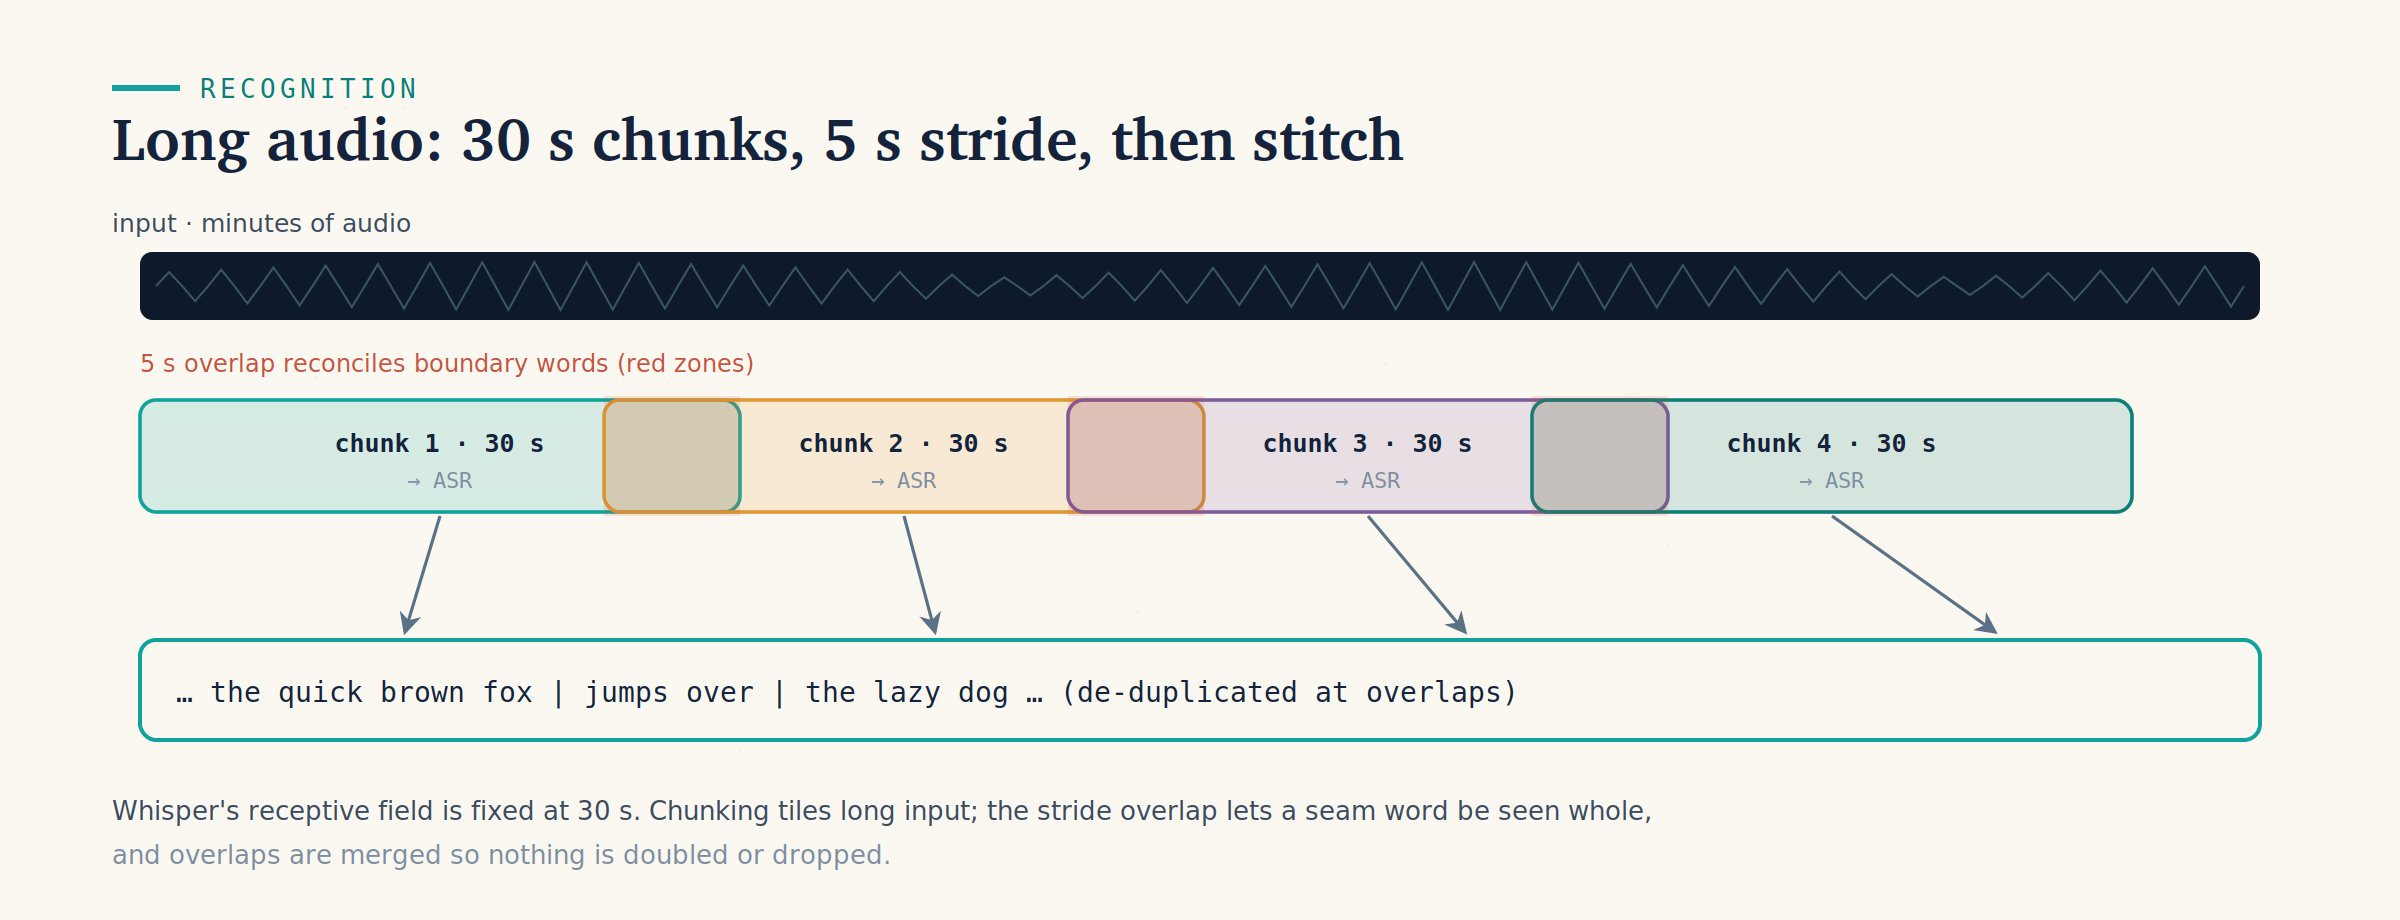
<sub><i>30 s chunks with 5 s stride; the overlapping regions (red) are reconciled into one continuous, de-duplicated transcript.</i></sub>

In [38]:
# Chunked, timestamped transcription of a >30 s clip. Falls back to tiling our
# short clip if the long dataset is unreachable (concept still demonstrated).
if _ASR_READY:
    from transformers import pipeline
    asr = pipeline("automatic-speech-recognition", model=model,
                   tokenizer=processor.tokenizer,
                   feature_extractor=processor.feature_extractor,
                   device=pipe_device, chunk_length_s=30, stride_length_s=5,
                   return_timestamps=True)
    try:
        from datasets import load_dataset
        clip = load_dataset("distil-whisper/librispeech_long", "clean",
                            split="validation")[0]["audio"]
        wav, csr = np.asarray(clip["array"], np.float32), clip["sampling_rate"]
    except Exception as e:
        print("long clip unavailable (", type(e).__name__, ") -> tiling to ~35 s.")
        reps = max(1, int(np.ceil(35 * SR / len(y16))))
        wav, csr = np.tile(y16, reps), SR
    print(f"clip: {len(wav)/csr:.1f} s (> 30 s -> chunked)\n")
    out = asr({"raw": wav, "sampling_rate": csr})
    for ch in out["chunks"][:6]:
        a, b = ch["timestamp"]                  # robust to None at chunk edges
        a = 0.0 if a is None else float(a)
        b = a if b is None else float(b)
        print(f"[{a:6.2f}s -> {b:6.2f}s] {ch['text'].strip()}")
else:
    print("[skipped] needs Whisper. Expected: timestamped chunks like '[ 0.00s -> 4.80s] ...'.")

Passing `generation_config` together with generation-related arguments=({'return_timestamps'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Using `chunk_length_s` is very experimental with seq2seq models. The results will not necessarily be entirely accurate and will have caveats. More information: https://github.com/huggingface/transformers/pull/20104. Ignore this warning with pipeline(..., ignore_warning=True). To use Whisper for long-form transcription, use rather the model's `generate` method directly as the model relies on it's own chunking mechanism (cf. Whisper original paper, section 3.8. Long-form Transcription).


long clip unavailable ( RuntimeError ) -> tiling to ~35 s.
clip: 35.1 s (> 30 s -> chunked)



RuntimeError: Could not load libtorchcodec. Likely causes:
          1. FFmpeg is not properly installed in your environment. We support
             versions 4, 5, 6, 7, and 8, and we attempt to load libtorchcodec
             for each of those versions. Errors for versions not installed on
             your system are expected; only the error for your installed FFmpeg
             version is relevant. On Windows, ensure you've installed the
             "full-shared" version which ships DLLs.
          2. The PyTorch version (2.10.0) is not compatible with
             this version of TorchCodec. Refer to the version compatibility
             table:
             https://github.com/pytorch/torchcodec?tab=readme-ov-file#installing-torchcodec.
          3. Another runtime dependency; see exceptions below.

        The following exceptions were raised as we tried to load libtorchcodec:
        
[start of libtorchcodec loading traceback]
FFmpeg version 8:
Traceback (most recent call last

#### 💡 Knowledge Check: Chunking long audio
**Q: Transcribing a 5-minute podcast, you already set `chunk_length_s=30`. Why add `stride_length_s=5` on top of it?**

A) It shortens each 30 s window to save memory  
B) It makes Whisper emit a timestamp every 5 seconds  
C) It overlaps chunks so words on a seam survive  
D) It limits the audio to five distinct speakers  

**Correct Answer: C**  
*Explanation: Naive 30 s cuts slice words in half at the seams. A 5 s overlap lets a boundary word appear whole in the neighbouring chunk, and the overlap is then de-duplicated.*

## 6 · Giving it a voice: Text-to-Speech (≈12 min)

ASR was audio → text. **TTS is text → audio** — the other half of any voice
product. The landscape:

| Option | Examples | When |
|---|---|---|
| **Open local models** | Kokoro, Piper, Coqui XTTS, MMS-TTS, Parler-TTS | no per-call cost, on-prem/private, you own latency |
| **APIs** | OpenAI TTS, ElevenLabs, Cartesia, PlayHT | best quality/voices, streaming, zero infra |

Knobs that matter: **voice** (speaker identity), **speed**, **output
format/sample rate** (often **24 kHz** — note the mismatch with 16 kHz ASR!),
and **streaming** (start playing before the whole sentence is synthesized — the
key to low-latency agents).

Below: a small open model so it runs in class with no API key. The API pattern
follows right after.

In [ ]:
# Local TTS with a light open model -- no API key, runs on CPU. Guarded.
tts = None; tts_audio = None
if HF_OK and TORCH_OK:
    try:
        from transformers import pipeline
        tts = pipeline("text-to-speech", model=TTS_MODEL_ID, device=pipe_device)
        out = tts("Audio is just an array of numbers, and sample rate is king.")
        tts_audio, tts_sr = np.asarray(out["audio"]).squeeze(), out["sampling_rate"]
        print(f"synthesized {len(tts_audio)/tts_sr:.1f}s @ {tts_sr} Hz")
        print(f"NOTE: TTS rate varies by model (OpenAI 24k, many 22.05k, this one"
              f" {tts_sr}). If it != your ASR's 16000, resample before feeding back.")
        display(Audio(tts_audio, rate=tts_sr))
    except Exception as e:
        print("TTS model not loaded (", type(e).__name__,
              "). Expected: a spoken version of the sentence.")
else:
    print("[skipped] TTS needs transformers+torch. Expected: text -> spoken audio.")

In [ ]:
# Production pattern with a managed API (commented -- needs OPENAI_API_KEY).
# Shape is the same everywhere: text in, audio bytes out, you pick voice +
# format. Streaming variants start returning audio before the sentence ends.
#
# from openai import OpenAI
# client = OpenAI()
# resp = client.audio.speech.create(
#     model="gpt-4o-mini-tts",   # or tts-1 / tts-1-hd
#     voice="alloy",             # the "voice" knob
#     input="Hello from the voice agent.",
#     response_format="wav",     # wav/mp3/opus; opus for low-latency streaming
# )
# resp.stream_to_file("reply.wav")
print("API TTS pattern shown above (commented). Same idea across providers.")

#### 💡 Knowledge Check: TTS → ASR hand-off
**Q: Your TTS model emits 24 kHz audio. You feed it straight into a 16 kHz ASR model with `sampling_rate=16000`. What happens?**

A) Nothing; the sample rate is only metadata  
B) It plays slower but ASR still reads it fine  
C) ASR auto-detects and resamples it for you  
D) ASR misreads it; the rate no longer matches  

**Correct Answer: D**  
*Explanation: Declaring 16 kHz for 24 kHz audio stretches it in time and shifts every frequency, so the model's input is corrupted. Resample 24 kHz → 16 kHz first; nothing fixes this automatically.*

## 7 · Putting it together: the voice-agent loop (≈12 min)

Every voice product — phone bot, meeting assistant, talking app — is the same
**cascade**: `mic → VAD → ASR → LLM → TTS → speaker`.

- **VAD** — is someone speaking, and did they stop? (endpointing)
- **ASR** — turn the speech into words
- **LLM** — decide what to say
- **TTS** — turn the reply back into audio

The hard part isn't any one box — it's the **latency budget**, because humans
notice a reply that takes more than ~800 ms to *start*:

| Stage | Typical latency | How to cut it |
|---|---|---|
| VAD / endpointing | 10–50 ms | tune silence threshold; don't over-wait to decide the user stopped |
| ASR | 100–500 ms | streaming / partial transcripts; smaller model |
| LLM | 300 ms – seconds | **stream tokens**; start TTS on the first sentence |
| TTS | 100–400 ms to first audio | **streaming TTS**; emit per-sentence, not per-paragraph |

Two senior-level ideas:
- **Stream everything and overlap stages.** Don't wait for the full transcript
  to call the LLM, or the full reply to start TTS. Pipeline them.
- **Barge-in / interruption.** When the user starts talking, VAD must detect it
  and *stop* the TTS immediately. Handling interruption is what separates a toy
  from a usable agent.

### Cascade vs. audio-native (multimodal)
The cascade uses three models. The newer alternative is an **audio-native
multimodal LLM** — GPT-4o-audio, Gemini — that takes audio **directly** as input
(and some emit audio directly: speech-to-speech). No ASR/TTS glue, lower
latency, and it can use *tone/prosody* the transcript throws away. Trade-off:
less control per stage and harder to debug. **Rule of thumb: cascade when you
need control/observability/cheap parts; audio-native when you need the lowest
latency and tone-awareness.**

In [ ]:
# Capstone: a tiny end-to-end audio->audio round trip, all guarded.
#   1) ASR  : reuse the Whisper hypothesis from §4 (hear the user)
#   2) "LLM": a trivial stand-in so this runs offline -- swap in a real
#             Claude/GPT chat call in production (one request)
#   3) TTS  : speak the reply
_ar  = globals().get("_ASR_READY", False)
_hyp = globals().get("hyp", None)
user_text = _hyp if (_ar and _hyp) else "mister quilter is the apostle of the middle classes"
print("1) ASR heard       :", user_text)

# --- stand-in for the LLM step (replace with a real API call in prod) --------
# e.g. Anthropic: client.messages.create(model="claude-...", messages=[...])
reply_text = f"You said: {user_text.strip().rstrip('.')}. Got it."
print("2) LLM would reply :", reply_text)

# --- speak it ---------------------------------------------------------------
if tts is not None:
    try:
        spoken = tts(reply_text)
        print("3) TTS speaks the reply:")
        display(Audio(np.asarray(spoken["audio"]).squeeze(), rate=spoken["sampling_rate"]))
    except Exception as e:
        print("3) [TTS skipped]", type(e).__name__)
else:
    print("3) [TTS skipped] -- with the TTS model loaded you'd hear the reply spoken.")

#### 💡 Knowledge Check: Latency budget
**Q: Users notice lag when a reply takes more than ~800 ms to *start*. Which single change most directly cuts that time-to-first-sound?**

A) Switching to a larger, more accurate ASR model  
B) Streaming TTS so playback starts before the reply ends  
C) Raising the TTS output sample rate to 48 kHz  
D) Buffering the whole reply before playback begins  

**Correct Answer: B**  
*Explanation: Time-to-first-sound depends on when audio starts, not on total compute. Streaming TTS plays the first chunk while the rest is still being generated; a bigger ASR model and full buffering both add delay.*

## 8 · Recap, gotchas, and exercises

### Cheat-sheet — the representations
| Representation | Shape | Used by |
|---|---|---|
| Waveform | `(samples,)` float32 [-1,1] | everything; the raw input |
| Log-mel | `(80, ~100·sec)` | Whisper / most speech encoders |
| Token ids | `(seq_len,)` | Whisper decoder → text |
| TTS output | `(samples,)` @ varies (e.g. 24 kHz) | playback (resample for ASR!) |

### The production gotcha list (screenshot this)
1. **Sample rate must match the model** (e.g. 16k ASR, 24k TTS, 48k music/audio models) — and be
   passed *consistently*. The #1 bug.
2. **Mono, float32 [-1,1]** before any model; average stereo channels.
3. **VAD before ASR** — kills most Whisper hallucinations.
4. **Whisper invents filler on silence** ("thank you", "thanks for watching")
   and can loop — VAD + thresholds + `condition_on_previous_text=False`.
5. **Always set `language`** if you know it.
6. **Long audio → chunk with stride**, never hard-cut at 30 s.
7. **Report normalized WER**, not raw.
8. **Decode `.mp3/.m4a` via ffmpeg/soundfile**, not raw byte parsing; dodge the
   `torchcodec` path in new `datasets`.
9. **Latency = stream + overlap stages**; handle barge-in.

### Troubleshooting
| Symptom | Likely cause | Fix |
|---|---|---|
| Transcript empty / wrong speed | sample-rate mismatch | resample to 16 kHz **and** pass `sampling_rate=16000` |
| "Thank you." on silence | hallucination prior | VAD-gate; raise `no_speech_threshold` |
| Same phrase repeats forever | decoder loop | `temperature=0` fallback; `condition_on_previous_text=False` |
| Words cut at boundaries | hard 30 s split | `chunk_length_s` + `stride_length_s` |
| Harsh/metallic resample | no anti-alias (`wav[::k]`) | `librosa.resample` |
| `torchcodec`/ffmpeg decode error | new `datasets` audio path | `Audio(decode=False)` + `soundfile` |
| TTS output transcribes badly | 24 kHz fed to a 16 kHz model | resample TTS output to 16 kHz first |

### Exercises
1. **Swap the ASR model** to `openai/whisper-large-v3-turbo`; re-run §4 WER. How
   much does normalized WER improve, and at what latency cost?
2. **Break & fix sample rate.** Feed the §6 TTS output (24 kHz) straight into
   Whisper without resampling, observe the garbage, then fix it with one
   `librosa.resample` line.
3. **VAD-gate a noisy clip.** Prepend 5 s of silence to the clip, transcribe
   with and without the Silero VAD step, and show the hallucination disappear.
4. **Close the loop for real.** Replace the §7 stand-in "LLM" with a real
   Claude/GPT call so the spoken reply is model-generated.

### References
- **Whisper** — *Robust Speech Recognition via Large-Scale Weak Supervision*
  (Radford et al., 2022).
- **Silero VAD** — github.com/snakers4/silero-vad.
- **pyannote.audio** — speaker diarization toolkit.
- HF `transformers` audio feature extractors implement the canonical
  25/10 ms · 80-band log-mel config used above.

---
*End. Runs top-to-bottom: §1–§3 always; §4–§7 load real models and otherwise
print a clear notice + expected output. A model never hears sound — it eats a
tensor. Get the tensor right.*